# Vessel Analysis

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np

import anndata as ad
import scanpy as sc
# import scimap as sm

import seaborn as sns
import matplotlib.pyplot as plt
# from matplotlib.pyplot import rc_context

import warnings
warnings.filterwarnings('ignore')

## 2. Lymph Node create anndata object

In [ ]:
annotDF = pd.read_csv('C:/Users/smith6jt/Spleen/Vessel_marker_intensities_LN_all_SpVesClass.csv')
annotDF.reset_index(drop=True,inplace=True)
list(annotDF.columns.tolist())

In [ ]:
annotDF.isna().sum()

In [ ]:
annotDF.fillna(1, inplace=True)
annotDF.isna().sum()

In [ ]:
spatialCols = ['Image',
 'Object ID',
 'Parent',
 'Centroid X µm',
 'Centroid Y µm',
]

spatialNames = {'Image':'imageid',
 'Object ID':'Object ID',
 'Parent':'Parent',
 'Centroid X µm':'X_centroid',
 'Centroid Y µm':'Y_centroid',
}                

spatDF = annotDF[spatialCols]
spatDF.rename(columns=spatialNames, inplace=True)

spatDF['imageid'] = spatDF['imageid'].apply(lambda x: x.split('.')[0])
spatDF['imageid'] = spatDF['imageid'].apply(lambda x: x.split('_n')[0])
spatDF

In [ ]:
# # Create a boolean mask for rows to keep
# keep_mask = spatDF['Parent'] != 'Root object (Image)'

# # Filter both dataframes using the mask
# spatDF = spatDF[keep_mask]
# annotDF = annotDF[keep_mask]
annotDF = annotDF.drop(['Image',
 'Object ID',
 'Object type',
 'Name',
 'ROI',
 'Classification',
 'Parent',
 'Centroid X µm',
 'Centroid Y µm',
], axis=1)

In [ ]:
list(annotDF.columns.tolist())

In [ ]:
annotDF.rename(columns={
 'Area µm^2':'Area',
 'Length µm':'Length',
 'Max diameter µm':'Max_Diameter',
 'Min diameter µm':'Min_Diameter',
  'Circularity':'Circularity',
 'Perimeter µm':'Perimeter'}, inplace=True)

In [ ]:
newNames = {col:col.split(' ')[5] for col in annotDF.columns[0::] if 'ROI' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

In [ ]:
newNames = {col:col.split(':')[0] for col in annotDF.columns[0::] if ':' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify marker columns to be normalized (assuming they are not the morphological features)
morph_features = ['Area', 'Length', 'Circularity', 'Max_Diameter', 'Solidity', 'Min_Diameter','Perimeter']
marker_columns = [col for col in annotDF.columns if col not in morph_features]

# Create a scaler object
scaler = MinMaxScaler()

# Fit and transform the marker columns
annotDF[marker_columns] = scaler.fit_transform(annotDF[marker_columns])

annotDF.head()

In [ ]:
vdata = ad.AnnData (annotDF)
vdata.obs = spatDF

print("Before standardization:")
print(vdata.obs.Parent.value_counts())

In [ ]:
vdata = ad.AnnData (annotDF)
vdata.obs = spatDF

print("Before standardization:")
print(vdata.obs.Parent.value_counts())

replacement_map = {
    'Cortices_Sinuses': 'Cortex/Paracortex',
    'Cortices_sinuses': 'Cortex/Paracortex',
    'Sinuses_cortices': 'Cortex/Paracortex',
    'Cortices_medulla': 'Capsule/Sinus/Medulla',
    'Medulla':'Capsule/Sinus/Medulla',
    'Root object (Image)': 'Border'
}

vdata.obs['Parent'] = vdata.obs['Parent'].replace(replacement_map)

print("\nAfter standardization:")
print(vdata.obs.Parent.value_counts())

print("\nUnique values after standardization:")
print(vdata.obs.Parent.unique())

In [ ]:
vdata.write_h5ad('/users/smith6jt/Spleen/all_LN_vessels_markers_SpVesClass.h5ad')

## 3. Lymph Node create charts

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/sscore/all_LN_vessels_markers.h5ad')

In [ ]:
vessel_df = pd.DataFrame({
    'Sample': vdata.obs['imageid'],
    'Region': vdata.obs['Parent'],
    'Area': vdata[:, 'Area'].X.flatten(), 
    'Length': vdata[:, 'Length'].X.flatten(), 
    'Solidity': vdata[:, 'Solidity'].X.flatten(), 
    'Max_Diameter': vdata[:, 'Max_Diameter'].X.flatten(), 
    'Min_Diameter': vdata[:, 'Min_Diameter'].X.flatten(),
    'ECAD': vdata[:, 'ECAD'].X.flatten(), 
    'Lyve1': vdata[:, 'Lyve1'].X.flatten(),
    'CollagenIV': vdata[:, 'CollagenIV'].X.flatten(),
    'CD31': vdata[:, 'CD31'].X.flatten(),
    'CD34': vdata[:, 'CD34'].X.flatten(),
    'Vimentin': vdata[:, 'Vimentin'].X.flatten(),
    'SMActin': vdata[:, 'SMActin'].X.flatten(),
    'CD44': vdata[:, 'CD44'].X.flatten(),
    'Podoplanin': vdata[:, 'Podoplanin'].X.flatten()
})
vessel_df = vessel_df.drop(vessel_df[vessel_df['Region'] == 'Root object (Image)'].index)
vessel_df['Region'] = vessel_df['Region'].astype(str).astype('category')
vessel_df = vessel_df[(vessel_df[['Area', 'Length', 'Solidity', 'Max_Diameter', 'Min_Diameter','ECAD', 'Lyve1','CollagenIV','CD31',
       'CD34','Vimentin','SMActin','CD44',
       'Podoplanin']]> 0).all(axis=1)] #& (vessel_df['Max_Diameter'] <= 150)]

print("Region counts:")
print(vessel_df['Region'].value_counts())

print('\nVessel Diameter Summary by Sample and Region:')
print(vessel_df.groupby(['Sample', 'Region'])['Area'].describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

In [ ]:
# Create a grouped box plot with jittered points
plt.figure(figsize=(8, 10))

plot_data = vessel_df[(vessel_df['Sample'] == '20_06_N1_R2') & ((vessel_df['Region'] == 'Medulla') | (vessel_df['Region'] == 'Cortex_Sinus'))]

# Create box plot
ax = sns.boxplot(x='Region', y='Max_Diameter', data=plot_data,
                 palette=['white', 'white'], showfliers=False, width=0.1, linewidth=5)

# Overlay individual data points with jitter
sns.swarmplot(x='Region', y='Max_Diameter', data=plot_data,
              palette=['green', 'magenta'], dodge=False, alpha=0.6, size=2, ax=ax)

plt.ylim(bottom=0)
plt.title('Vessel Max Diameter Comparison: Medulla vs Cortex_Sinus', fontsize=22)
# plt.xlabel('Region', fontsize=18)
plt.ylabel('Max_Diameter (μm)', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Handle legend
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles[:2], labels[:2], title='Region', fontsize=14, title_fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def assign_donor(sample_name):
    if '6' in sample_name:
        return 'Donor 1 (21F)'
    elif '8' in sample_name:
        return 'Donor 2 (10M)'
    elif '9' in sample_name:
        return 'Donor 3 (32M)'
    else:
        return 'Unknown'

# Add donor column to your dataframe
vessel_df['Donor'] = vessel_df['Sample'].apply(assign_donor)

print("\nDonor groupings:")
print(vessel_df.groupby('Donor')['Sample'].unique())

In [ ]:
# Create combined plot with all donors, points colored by sample
plt.figure(figsize=(22, 7))

regions_to_plot = ['Cortex/Paracortex', 'Capsule/Sinus/Medulla']
plot_data = vessel_df[vessel_df['Region'].isin(regions_to_plot)]

max_diameter = 30  # Set your desired maximum value
plot_data = plot_data[plot_data['Min_Diameter'] <= max_diameter]

# Create positions for each donor-region combination with spacing
donors = sorted(plot_data['Donor'].unique())
regions = regions_to_plot
spacing = 1.5  # Space between donors
region_spacing = 1  # Space between regions within a donor

# Calculate x positions
x_positions = {}
x_labels = []
x_ticks = []
donor_centers = []

current_x = 0
for donor_idx, donor in enumerate(donors):
    donor_start = current_x
    for region_idx, region in enumerate(regions):
        x_positions[(donor, region)] = current_x
        x_ticks.append(current_x)
        # Shorten region names for x-axis
        region_short = region.replace('/', '/\n')  # Add line break for long names
        if 'Cortex' in region:
            region_short = 'Cortex/\nParacortex'
        elif 'Capsule' in region:
            region_short = 'Capsule/Sinus/\nMedulla'
        x_labels.append(region_short)
        current_x += region_spacing
    
    # Calculate donor center position
    donor_end = current_x - region_spacing
    donor_centers.append((donor_start + donor_end) / 2)
    current_x += spacing  # Add space before next donor

# Create the plot
fig, ax = plt.subplots(figsize=(22, 8))

# Create box plots manually at specified positions
box_data = []
box_positions = []
for donor in donors:
    for region in regions:
        subset = plot_data[(plot_data['Donor'] == donor) & (plot_data['Region'] == region)]
        if len(subset) > 0:
            box_data.append(subset['Min_Diameter'].values)
            box_positions.append(x_positions[(donor, region)])

# Create box plots
bp = ax.boxplot(box_data, positions=box_positions, widths=0.6, 
                patch_artist=True, showfliers=False)

# Color the box plots
colors = ['lightblue', 'lightcoral'] * len(donors)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Create swarmplots for each donor-region combination, colored by sample
samples = plot_data['Sample'].unique()
sample_colors = {sample: plt.cm.tab10(i) for i, sample in enumerate(samples)}

for donor in donors:
    for region in regions:
        subset = plot_data[(plot_data['Donor'] == donor) & (plot_data['Region'] == region)]
        x_pos = x_positions[(donor, region)]
        
        if len(subset) > 0:
            for sample in subset['Sample'].unique():
                sample_data = subset[subset['Sample'] == sample]
                if len(sample_data) > 0:
                    # Add more jitter to spread points horizontally
                    x_jitter = np.random.normal(0, 0.25, len(sample_data))  # Increased jitter
                    x_positions_jittered = [x_pos + j for j in x_jitter]
                    
                    ax.scatter(x_positions_jittered, sample_data['Min_Diameter'],
                             c=[sample_colors[sample]], 
                             alpha=0.7, s=2)  # Increased point size

# Set up the axes
ax.set_ylim(bottom=0, top=max_diameter)
ax.set_xlim(-1, max(x_ticks) + 1)

# Set x-axis labels for regions
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10)

# Add donor labels below region labels
for i, (donor, center) in enumerate(zip(donors, donor_centers)):
    ax.text(center, -max_diameter * 0.08, donor, 
            ha='center', va='top', fontsize=12, fontweight='bold')

# Add vertical lines to separate donors
for i in range(len(donors) - 1):
    separator_x = donor_centers[i] + (donor_centers[i+1] - donor_centers[i]) / 2
    ax.axvline(x=separator_x, color='gray', linestyle='--', alpha=0.3)

plt.title('Vessel Min Diameter Comparison Across Donors and Regions', fontsize=18)
plt.xlabel('', fontsize=14)  # Remove x-label since we have custom labels
plt.ylabel('Min Diameter (μm)', fontsize=14)
plt.yticks(fontsize=12)

# Only show sample legend
sample_handles = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=sample_colors[sample], 
                            markersize=8) for sample in samples]

plt.legend(sample_handles, samples, title='Sample', 
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adjust bottom margin to accommodate donor labels
# plt.subplots_adjust(bottom=0.01)

plt.show()

# Print how many points were excluded
total_points = len(vessel_df[vessel_df['Region'].isin(regions_to_plot)])
filtered_points = len(plot_data)
excluded_points = total_points - filtered_points
print(f"Excluded {excluded_points} points above {max_diameter}μm ({excluded_points/total_points*100:.1f}% of data)")

## 4. Lymph Node clustering

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/Spleen/all_LN_vessels_markers_SpVesClass.h5ad')

In [ ]:
vdata=vdata[vdata.obs['Parent'] != 'Root object (Image)']

In [ ]:
vdata = vdata[vdata[:, 'Min_Diameter'].X.flatten() <= 60]
vdata = vdata[vdata[:, 'Max_Diameter'].X.flatten() <= 100]
vdata = vdata[vdata[:, 'Area'].X.flatten() <= 1000]

In [ ]:
vdata = vdata[:, ['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter','Perimeter', 'Lyve1','CD31',
       'CD34', "SMActin", "Vimentin"]]

In [ ]:
# sc.pp.normalize_total(vdata)
# sc.pp.log1p(vdata)
# vdata.layers["scaled"] = sc.pp.scale(vdata, zero_center=True, copy=True).X
vdata.layers["raw"] = vdata.X.copy()

# Scale only for dimensionality reduction and clustering
# This will modify vdata.X but preserve raw values in layers["raw"]
sc.pp.scale(vdata, zero_center=True, max_value=1)

In [ ]:
vdata_temp = vdata.copy()
vdata_temp.X = vdata_temp.layers['raw']
sc.pp.pca(vdata_temp, svd_solver='arpack')

In [ ]:
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,10))
sc.pl.pca_variance_ratio(vdata_temp, n_pcs=30, log=True)

In [ ]:
vdata.var_names

In [ ]:
sc.pl.pca(vdata_temp, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], 
          annotate_var_explained=True)

In [ ]:
sc.pl.pca(vdata_temp, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'], annotate_var_explained=True)

In [ ]:
sc.pp.neighbors(vdata)
# sc.tl.paga(vdata, groups='Parent')
# sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,12))
# sc.pl.paga(vdata, fontsize=15, fontoutline= 2, layout='eq_tree', threshold=0.1, node_size_scale=8, cmap='tab20', max_edge_width=5)

In [ ]:
sc.tl.umap(vdata, min_dist=0.01, spread=2)

In [ ]:
sc.pl.umap(vdata, color=['imageid', 'Parent'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'],  size=30)

In [ ]:
sc.tl.leiden(vdata, resolution=0.2, key_added='leiden_Res0.2')

In [ ]:
vdata_2008_10 = vdata[vdata.obs['imageid'] == '20_08_N10_R1'].copy()

In [ ]:
sc.tl.dendrogram(vdata, groupby='leiden_Res0.2')

In [ ]:
vdata

In [ ]:
sc.pl.dotplot(vdata, var_names=vdata.var_names, log=False, groupby="leiden_Res0.2", dendrogram=True, use_raw=False, swap_axes=True, cmap='magma', figsize=(4, 5), vmin=-1.25, vmax=1.25)

In [ ]:
vdata.write_h5ad('/users/smith6jt/sscore/all_LN_vessels_markers_SpVesClass_2025July7.h5ad')

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/sscore/all_LN_vessels_markers_2025July3.h5ad')

In [ ]:
import napari
import tifffile as tiff

marker_names = ["CD107a",
"CD1c",
"CD11c",
"CD15",
"CD163",
"CD20",
"CD21",
"CD31",
"CD34",
"CD35",
"CD3e",
"CD4",
"CD45",
"CD45RO",
"CD5",
"CD68",
"CD8",
"CollagenIV",
"DAPI",
"ECAD",
"FoxP3",
"HLADR",
"Ki67",
"Lyve1",
"Podoplanin",
"SMActin",
"Vimentin"]
marker_image = tiff.imread("C:/Users/smith6jt/Lymph_Node_QP/Images/20_08_N10_R1.ome.tiff")

# vdata_2006 = vdata[vdata.obs['imageid'] == '20_06_N1_R2'].copy()C
clusters_df = vdata_2008_10.obs[['leiden_Res0.3','Y_centroid','X_centroid']]
unique_clusters = clusters_df['leiden_Res0.3'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

viewer = napari.Viewer()
viewer.add_image(marker_image, channel_axis=0, name=marker_names, rgb=False)

for i, cluster_id in enumerate(unique_clusters):
    cluster_points = clusters_df[clusters_df['leiden_Res0.3'] == cluster_id][['Y_centroid', 'X_centroid']].to_numpy()
    viewer.add_points(
        cluster_points*2.67,
        name=f'Cluster {cluster_id}',
        size=70,
        face_color=colors[i][:3],  
        opacity=0.7
    )


In [ ]:
vdata_2006.obsm['X_spatial'] = vdata_2006.obs[['X_centroid','Y_centroid']].values
fig,ax=plt.subplots(1,1,figsize=(12,12))
ax.invert_yaxis()
ax.axis('off')
sc.pl.scatter(vdata_2006, basis='spatial',color=['leiden_Res0.3'], ax=ax, size=38, legend_fontsize='x-large',
              alpha=0.9, palette='tab20', title='Leiden Res0.3')

In [ ]:

sc.pl.umap(vdata, color=['leiden_Res0.2'],
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False, palette='tab20', add_outline=True, outline_width=(0.1, 0.05), size=25, title='Leiden Clusters')

In [ ]:
vdata.obs.to_csv('/Users/smith6jt/Spleen/LN_vessels_clusters_SpVesClass.csv')

## 5. Spleen create anndata object

In [ ]:
annotDF = pd.read_csv('C:/Users/smith6jt/Spleen/spleen_regions.csv')
annotDF.reset_index(drop=True,inplace=True)
list(annotDF.columns.tolist())

In [ ]:
annotDF.isna().sum()

In [ ]:
nan_rows = annotDF[annotDF.isna().any(axis=1)]
if len(nan_rows) > 0:
    print(nan_rows.head())

In [ ]:
annotDF.fillna(1, inplace=True)
annotDF.isna().sum()

In [ ]:
list(annotDF.columns.tolist())

In [ ]:
annotDF.rename(columns={
 'Area µm^2':'Area',
 'Length µm':'Length',
 'Max diameter µm':'Max diameter',
 'Min diameter µm':'Min diameter',
  'Circularity':'Circularity',
 'Perimeter µm':'Perimeter'}, inplace=True)

In [ ]:
annotDF

In [ ]:
newNames = {col:col.split('.')[0] for col in annotDF.columns[0::] if '.' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

In [ ]:
newNames = {col:col.split('^')[0] for col in annotDF.columns[0::] if '^' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

In [ ]:
spatialCols = ['Image',
 'Parent',
 'Centroid X',
 'Centroid Y',
 'Area', 
 'Perimeter', 
 'Length', 
 'Circularity', 
 'Solidity',
'Max diameter', 
'Min diameter'
]

spatialNames = {'Image':'imageid',
 'Parent':'Parent',
 'Centroid X':'X_centroid',  
 'Centroid Y':'Y_centroid',
 'Area':'Area', 
 'Perimeter':'Perimeter', 
 'Length':'Length', 
 'Circularity': 'Circularity', 
 'Solidity':'Solidity',
'Max diameter':'Max diameter', 
'Min diameter':'Min diameter'
}                

spatDF = annotDF[spatialCols] 
spatDF.rename(columns=spatialNames, inplace=True)

# Create the filter mask
filter_mask = spatDF['imageid'] != 1

# Apply the same filter to both DataFrames
spatDF = spatDF[filter_mask]
annotDF = annotDF[filter_mask]

# Reset indices to ensure they align
spatDF.reset_index(drop=True, inplace=True)
annotDF.reset_index(drop=True, inplace=True)

spatDF

In [ ]:
annotDF

In [ ]:
# # Create a boolean mask for rows to keep
# keep_mask = spatDF['Parent'] != 'Root object (Image)'

# # Filter both dataframes using the mask
# spatDF = spatDF[keep_mask]
# annotDF = annotDF[keep_mask]
annotDF = annotDF.drop(['Image',

 'Classification',
 'Parent',
 'Centroid X',
 'Centroid Y',
  'Area', 
 'Perimeter', 
 'Length', 
 'Circularity', 
 'Solidity',
'Max diameter', 
'Min diameter'
], axis=1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Identify marker columns to be normalized (assuming they are not the morphological features)
morph_features = ['Area', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter','Perimeter']
marker_columns = [col for col in annotDF.columns if col not in morph_features]

# Create a scaler object
scaler = MinMaxScaler()

# Fit and transform the marker columns
annotDF[marker_columns] = scaler.fit_transform(annotDF[marker_columns])

annotDF.head()

In [ ]:
vdata_SP = ad.AnnData (annotDF)
vdata_SP.obs = spatDF

print("Before standardization:")
print(vdata_SP.obs.Parent.value_counts())

In [ ]:
replacement_map = {
    'Annotation (Red_Pulp)': 'Red_Pulp',
    'Annotation (White_Pulp)': 'White_Pulp',
    'Annotation (Sinusoid)': 'Sinusoid',
    'Annotation (Trabecula)': 'Trabecula',
    'Annotation (Artery)': 'Artery',
    'Annotation (Follicle)': 'Follicle',
    'Annotation (PALS)': 'PALS',
}

vdata_SP.obs['Parent'] = vdata_SP.obs['Parent'].replace(replacement_map)

print("\nAfter standardization:")
print(vdata_SP.obs.Parent.value_counts())

print("\nUnique values after standardization:")
print(vdata_SP.obs.Parent.unique())

In [ ]:
vdata_SP.write_h5ad('/users/smith6jt/Spleen/all_SP_vessels_markers_regions.h5ad')

## 6. Spleen clustering

In [17]:
vdata = sc.read_h5ad('/users/smith6jt/Spleen/all_SP_vessels_markers_regions.h5ad')

In [16]:
vdata

AnnData object with n_obs × n_vars = 15517 × 4
    obs: 'imageid', 'Parent', 'X_centroid', 'Y_centroid', 'Area', 'Perimeter', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter'
    uns: 'pca_combined'

In [18]:
# Complete PCA Analysis Including Shape, Marker, and Categorical Data

# Create a comprehensive dataset combining obs (shape + categorical) and var (markers)
vdata_pca = vdata.copy()

# Extract shape measurements from obs (numerical)
shape_features = ['Area', 'Length', 'Circularity', 'Min diameter']
shape_data = vdata_pca.obs[shape_features].values

# Extract categorical features from obs
categorical_features = ['Parent']  # Add other categorical columns as needed
print(f"Available categorical features: {vdata_pca.obs.select_dtypes(include=['object', 'category']).columns.tolist()}")

# One-hot encode categorical variables
from sklearn.preprocessing import LabelEncoder
import pandas as pd

categorical_data_list = []
categorical_feature_names = []

for cat_feature in categorical_features:
    if cat_feature in vdata_pca.obs.columns:
        # One-hot encoding for categorical variables
        cat_dummies = pd.get_dummies(vdata_pca.obs[cat_feature], prefix=cat_feature)
        categorical_data_list.append(cat_dummies.values)
        categorical_feature_names.extend(cat_dummies.columns.tolist())

# Combine all categorical data
if categorical_data_list:
    categorical_data = np.concatenate(categorical_data_list, axis=1)
else:
    categorical_data = np.empty((vdata_pca.shape[0], 0))

# Extract marker data (already in .X)
marker_data = vdata_pca.X.copy()
if 'scaled' in vdata_pca.layers:
    marker_data = vdata_pca.layers['scaled'].copy()

# Combine all data: shape + categorical + markers
combined_data = np.concatenate([shape_data, categorical_data, marker_data], axis=1)

# Create comprehensive feature names
shape_feature_names = shape_features
marker_feature_names = vdata_pca.var_names.tolist()
all_feature_names = shape_feature_names + categorical_feature_names + marker_feature_names

print(f"Shape features ({len(shape_feature_names)}): {shape_feature_names}")
print(f"Categorical features ({len(categorical_feature_names)}): {categorical_feature_names}")
print(f"Marker features ({len(marker_feature_names)}): {marker_feature_names}")
print(f"Total features: {len(all_feature_names)}")

Available categorical features: ['imageid', 'Parent']
Shape features (4): ['Area', 'Length', 'Circularity', 'Min diameter']
Categorical features (8): ['Parent_Border', 'Parent_Follicle', 'Parent_PALS', 'Parent_Peripheral_White_Pulp', 'Parent_Red_Pulp', 'Parent_Sinusoid', 'Parent_Trabecula', 'Parent_White_Pulp']
Marker features (4): ['CD31', 'CD34', 'Lyve1', 'SMActin']
Total features: 16


In [24]:
from adjustText import adjust_text

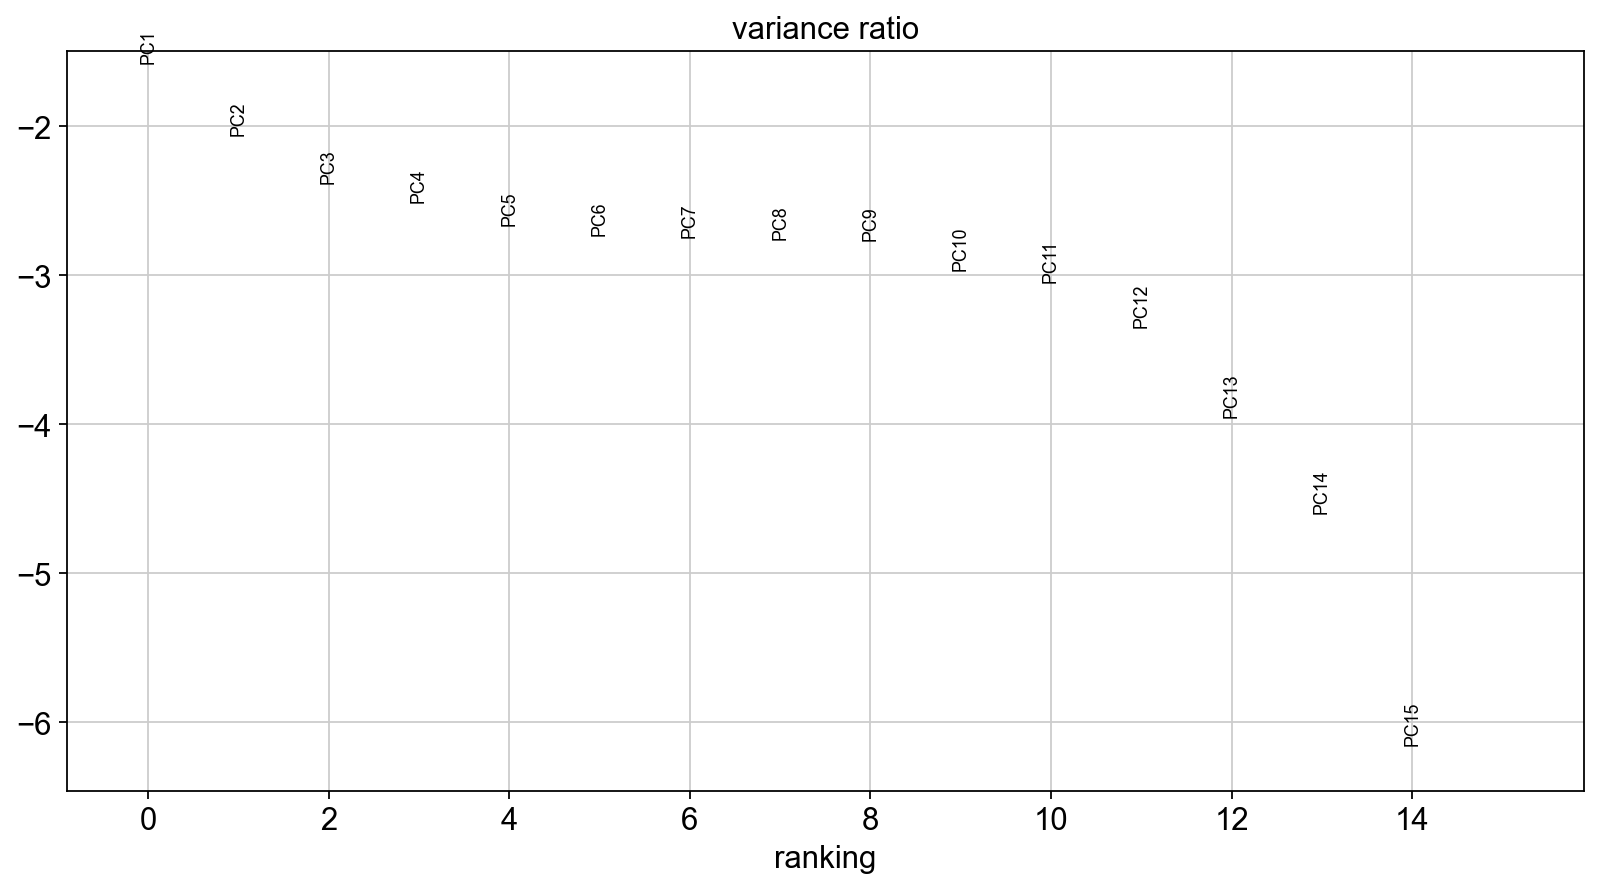


PCA Loadings (Variable Contributions):
                                   PC1       PC2       PC3       PC4  \
Area                          0.490756  0.197605  0.024958  0.080184   
Length                        0.510101  0.217686  0.002597 -0.033417   
Circularity                  -0.320678 -0.190183  0.147715  0.374845   
Min diameter                  0.485458  0.156437  0.040704  0.079001   
Parent_Border                 0.008813  0.049491 -0.200945  0.271518   
Parent_Follicle              -0.013287  0.001717 -0.233620  0.005640   
Parent_PALS                  -0.008714  0.013616 -0.279958  0.139701   
Parent_Peripheral_White_Pulp -0.032580  0.029193 -0.412673  0.044785   
Parent_Red_Pulp               0.217149 -0.471497  0.444148 -0.161547   
Parent_Sinusoid              -0.251955  0.510102  0.090444 -0.037629   
Parent_Trabecula              0.026575  0.030787 -0.200921  0.187840   
Parent_White_Pulp             0.024554  0.050631 -0.169026 -0.020514   
CD31                    

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


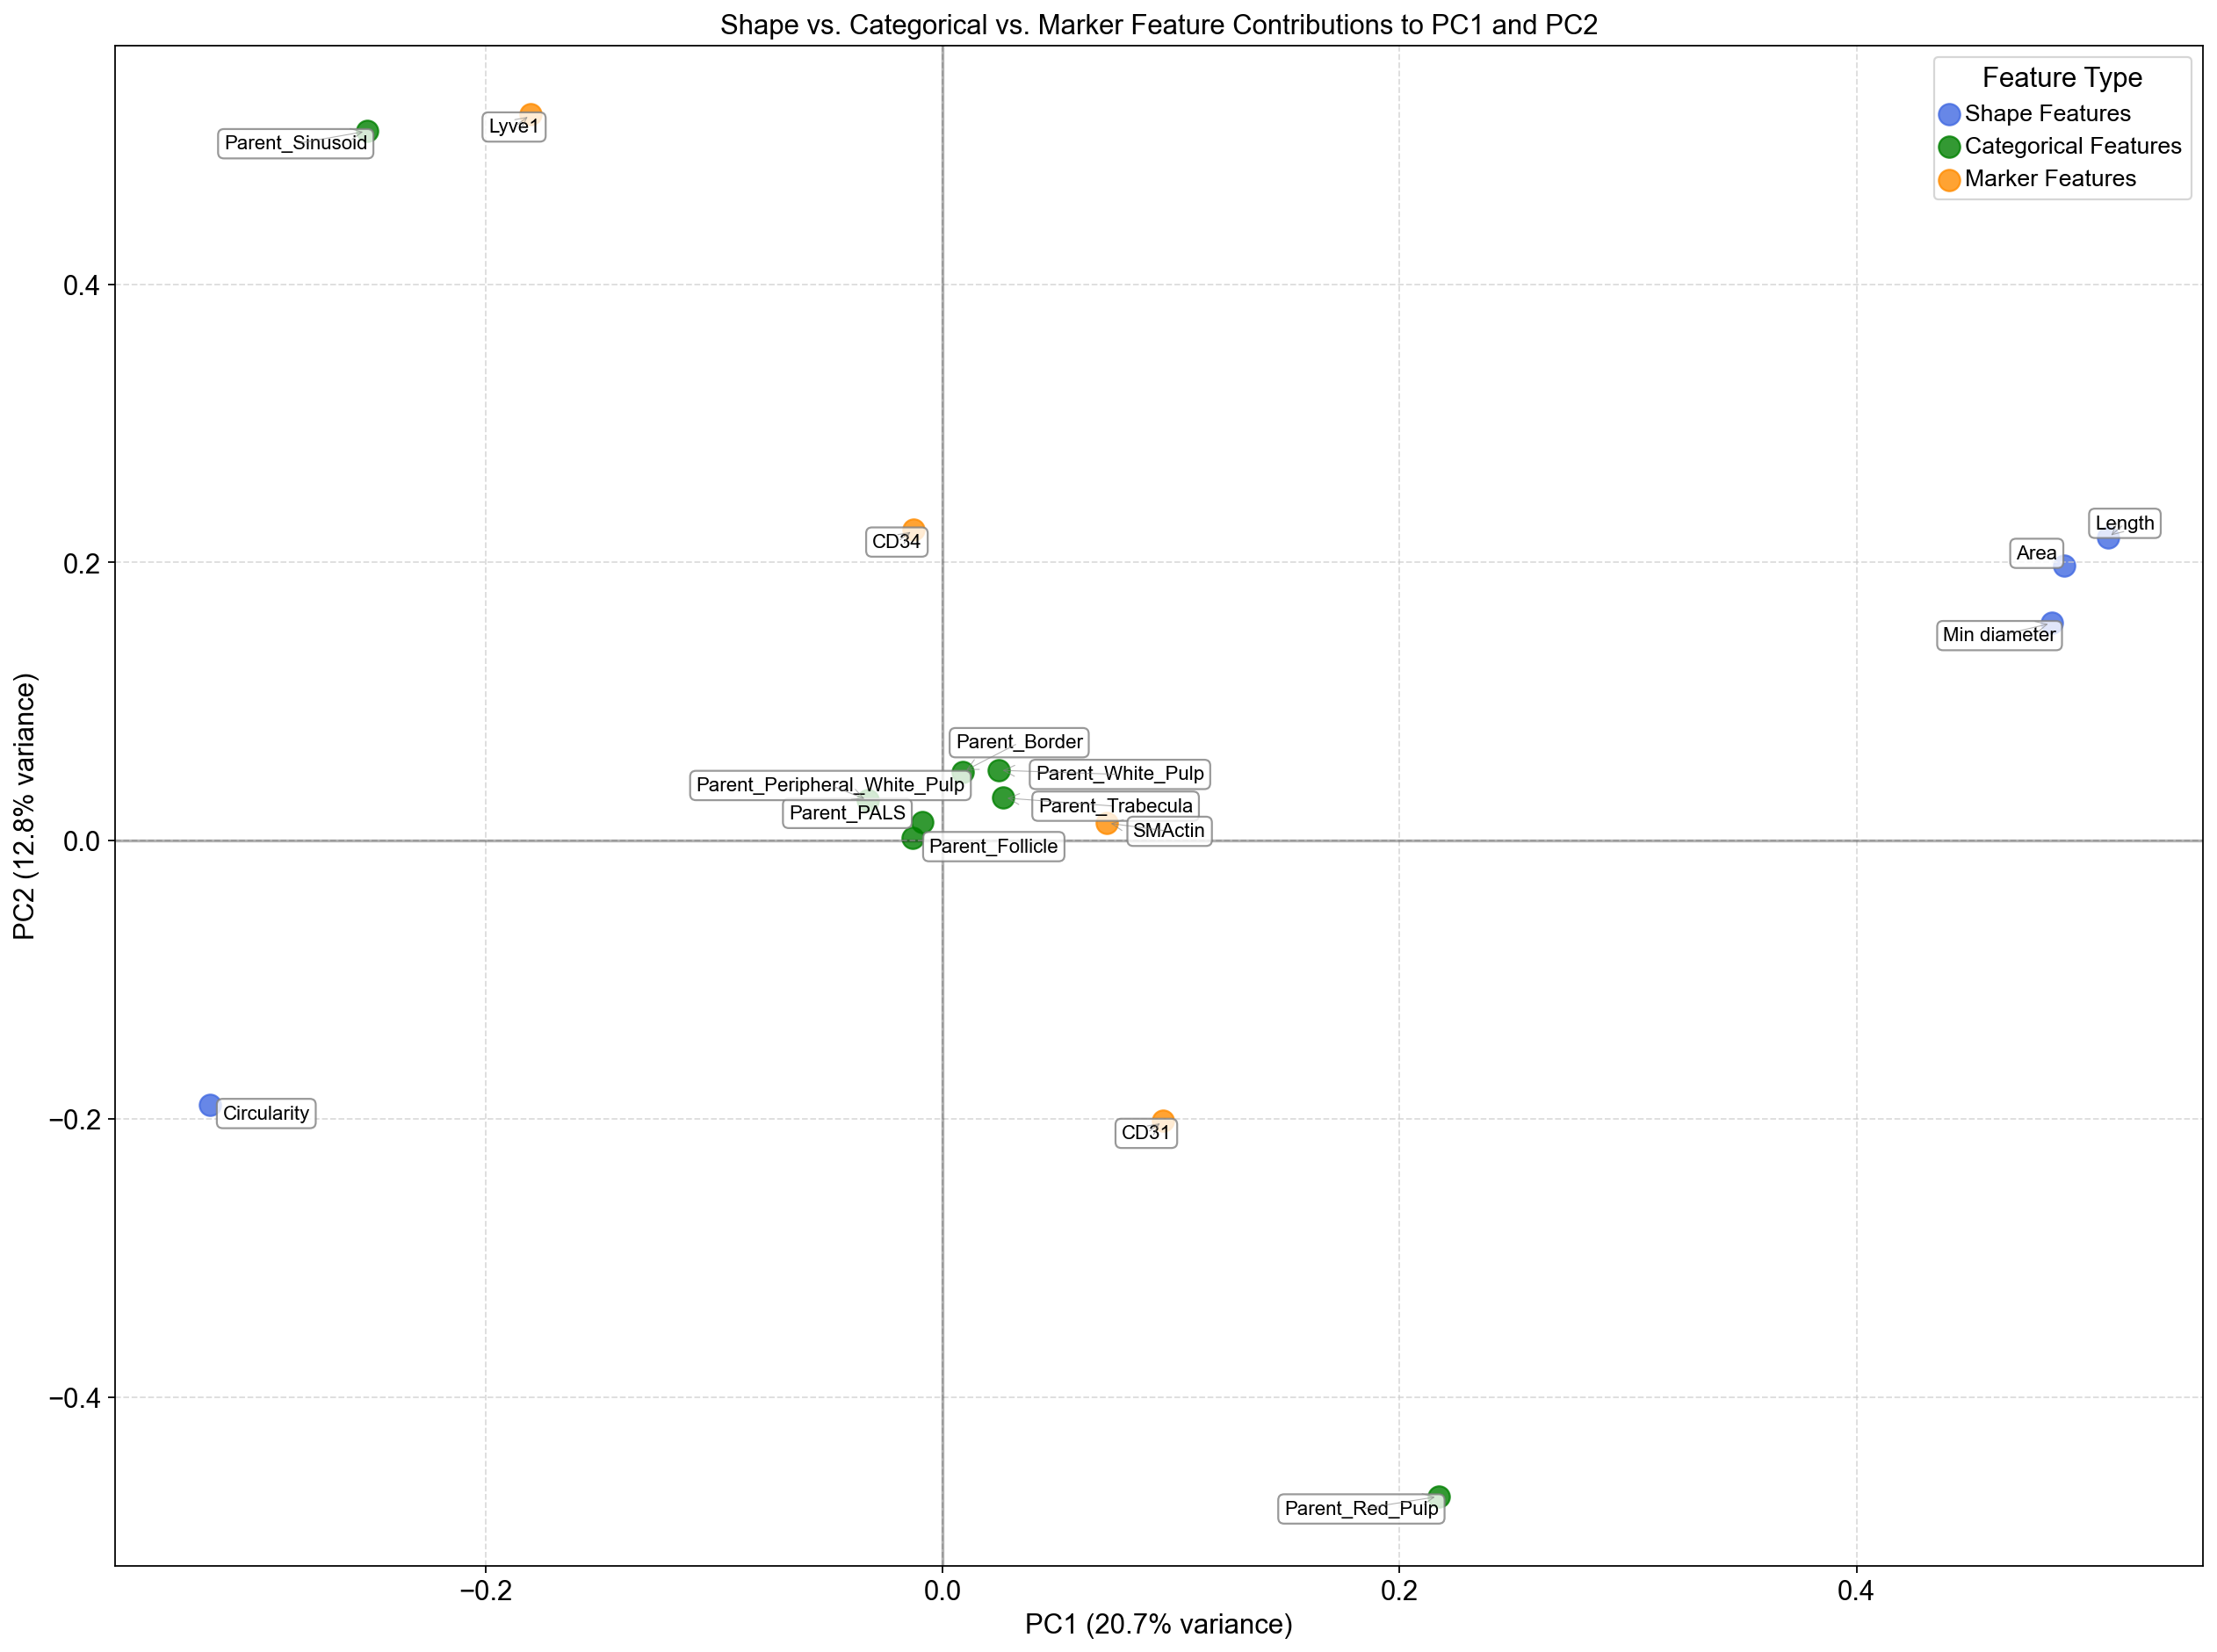

In [25]:
# Create a new AnnData object with combined data
combined_adata = ad.AnnData(X=combined_data)
combined_adata.obs = vdata_pca.obs.copy()
combined_adata.var_names = all_feature_names

# Standardize the combined data for PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
combined_adata.X = scaler.fit_transform(combined_adata.X)

# Run PCA
sc.pp.pca(combined_adata, svd_solver='arpack', n_comps=min(15, combined_adata.shape[1]-1))

# Plot variance ratio
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(12, 6))
sc.pl.pca_variance_ratio(combined_adata, n_pcs=15, log=True)

# Extract PCA loadings (variable contributions to each PC)
loadings = pd.DataFrame(
    combined_adata.varm['PCs'], 
    index=combined_adata.var_names, 
    columns=[f'PC{i+1}' for i in range(combined_adata.varm['PCs'].shape[1])]
)

# Add feature type column
def get_feature_type(feature_name):
    if feature_name in shape_feature_names:
        return 'Shape'
    elif feature_name in categorical_feature_names:
        return 'Categorical'
    else:
        return 'Marker'

loadings['Type'] = [get_feature_type(feature) for feature in loadings.index]

print("\nPCA Loadings (Variable Contributions):")
print(loadings.head(15))

# Visualize the loadings for the first two PCs with feature types highlighted
# Visualize the loadings for the first two PCs with feature types highlighted
plt.figure(figsize=(16, 12))
colors = {'Shape': 'royalblue', 'Categorical': 'green', 'Marker': 'darkorange'}

# Plot the points first
for feature_type in ['Shape', 'Categorical', 'Marker']:
    subset = loadings[loadings['Type'] == feature_type]
    if len(subset) > 0:
        plt.scatter(subset['PC1'], subset['PC2'], s=120, 
                   label=f'{feature_type} Features', 
                   alpha=0.8, color=colors[feature_type])

plt.grid(True, linestyle='--', alpha=0.7)

# Create annotations list for adjustText
texts = []
for i, row in loadings.iterrows():
    # Create text annotations without positioning them yet
    text = plt.annotate(i, (row['PC1'], row['PC2']), 
                       fontsize=10, ha='center', va='center',
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    texts.append(text)

# Adjust text positions to avoid overlaps
adjust_text(texts, 
           arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6, lw=0.5),
           expand_points=(1.2, 1.2),  # Expand around points
           expand_text=(1.1, 1.1),   # Expand around text
           force_points=0.5,         # Force to avoid points
           force_text=0.8)           # Force to avoid text overlap

# Add reference lines
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.xlabel(f'PC1 ({combined_adata.uns["pca"]["variance_ratio"][0]:.1%} variance)')
plt.ylabel(f'PC2 ({combined_adata.uns["pca"]["variance_ratio"][1]:.1%} variance)')
plt.title('Shape vs. Categorical vs. Marker Feature Contributions to PC1 and PC2')
plt.legend(title='Feature Type', fontsize=12)
plt.tight_layout()
plt.show()

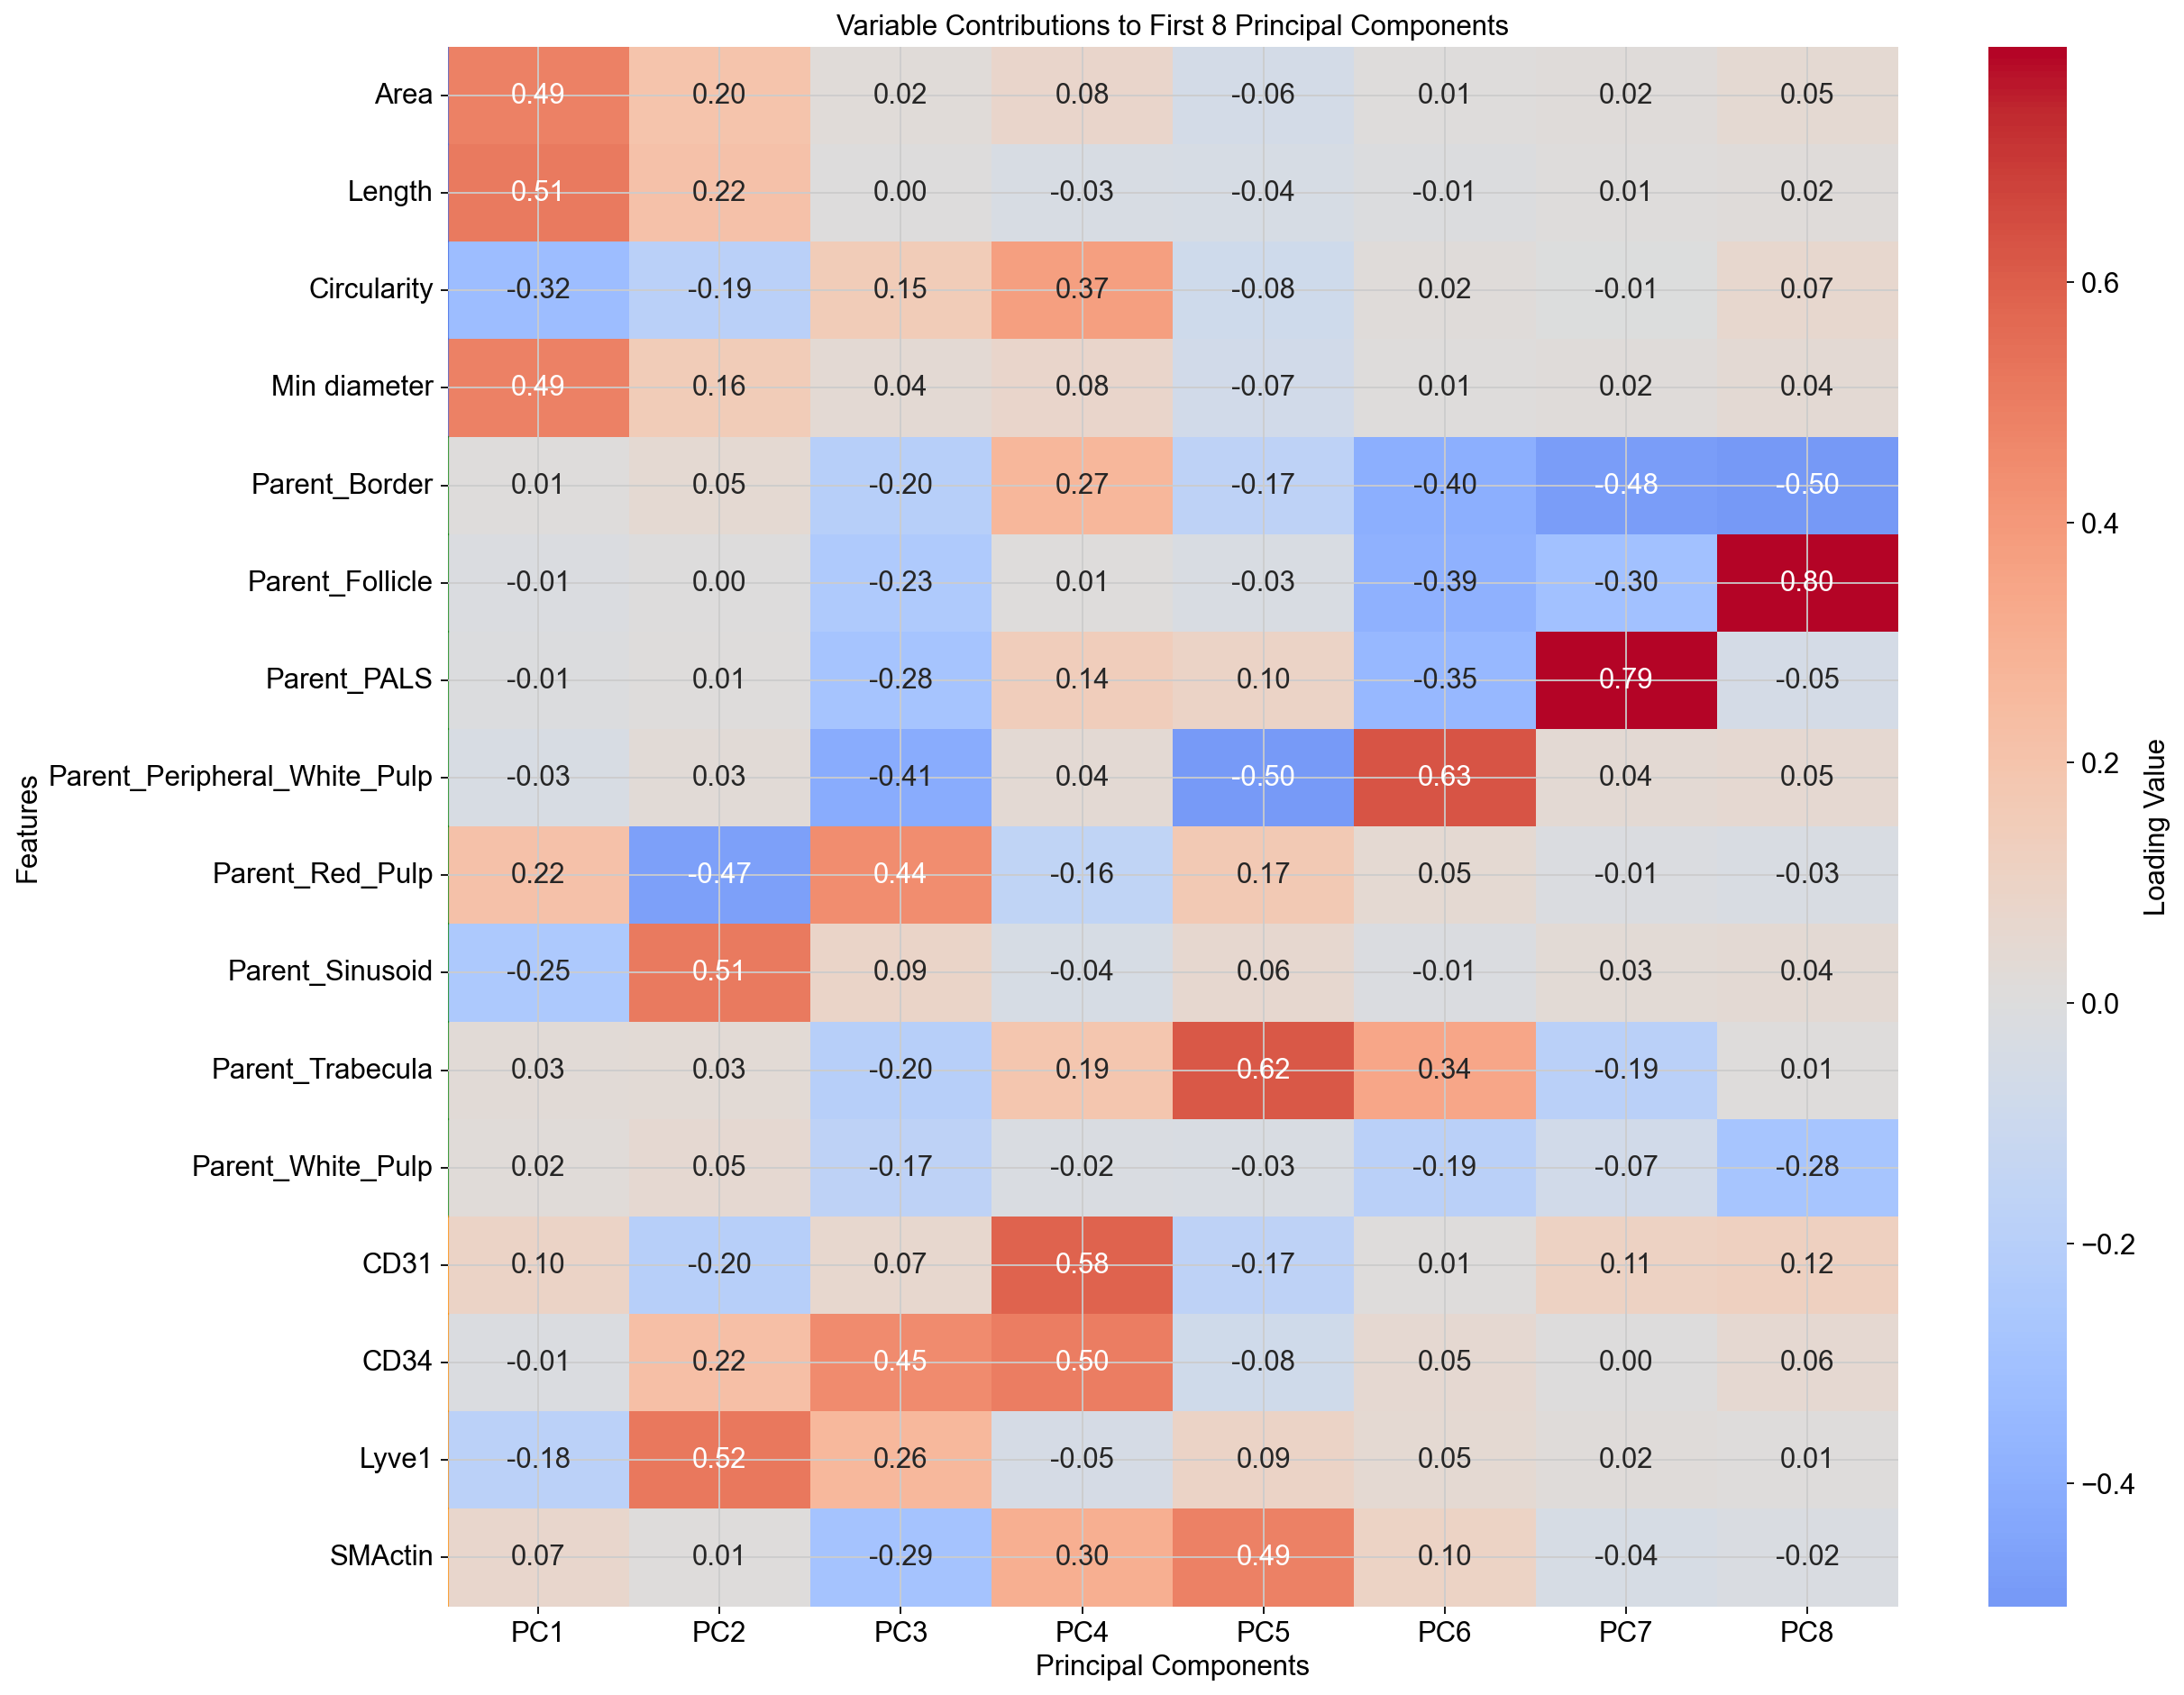

In [20]:
# Heatmap of loadings for first 8 PCs
plt.figure(figsize=(16, 12))
loadings_for_heatmap = loadings.iloc[:, :8]  # First 8 PCs

# Create the heatmap
sns.heatmap(loadings_for_heatmap, annot=True, cmap='coolwarm', center=0, fmt=".2f", 
            cbar_kws={'label': 'Loading Value'})
plt.title('Variable Contributions to First 8 Principal Components')
plt.ylabel('Features')
plt.xlabel('Principal Components')

# Add colored bars for feature types
for i, (idx, row) in enumerate(loadings.iterrows()):
    plt.gca().add_patch(plt.Rectangle((-0.5, i), 0.5, 1, 
                                     color=colors[row['Type']], alpha=0.7))

plt.tight_layout()
plt.show()

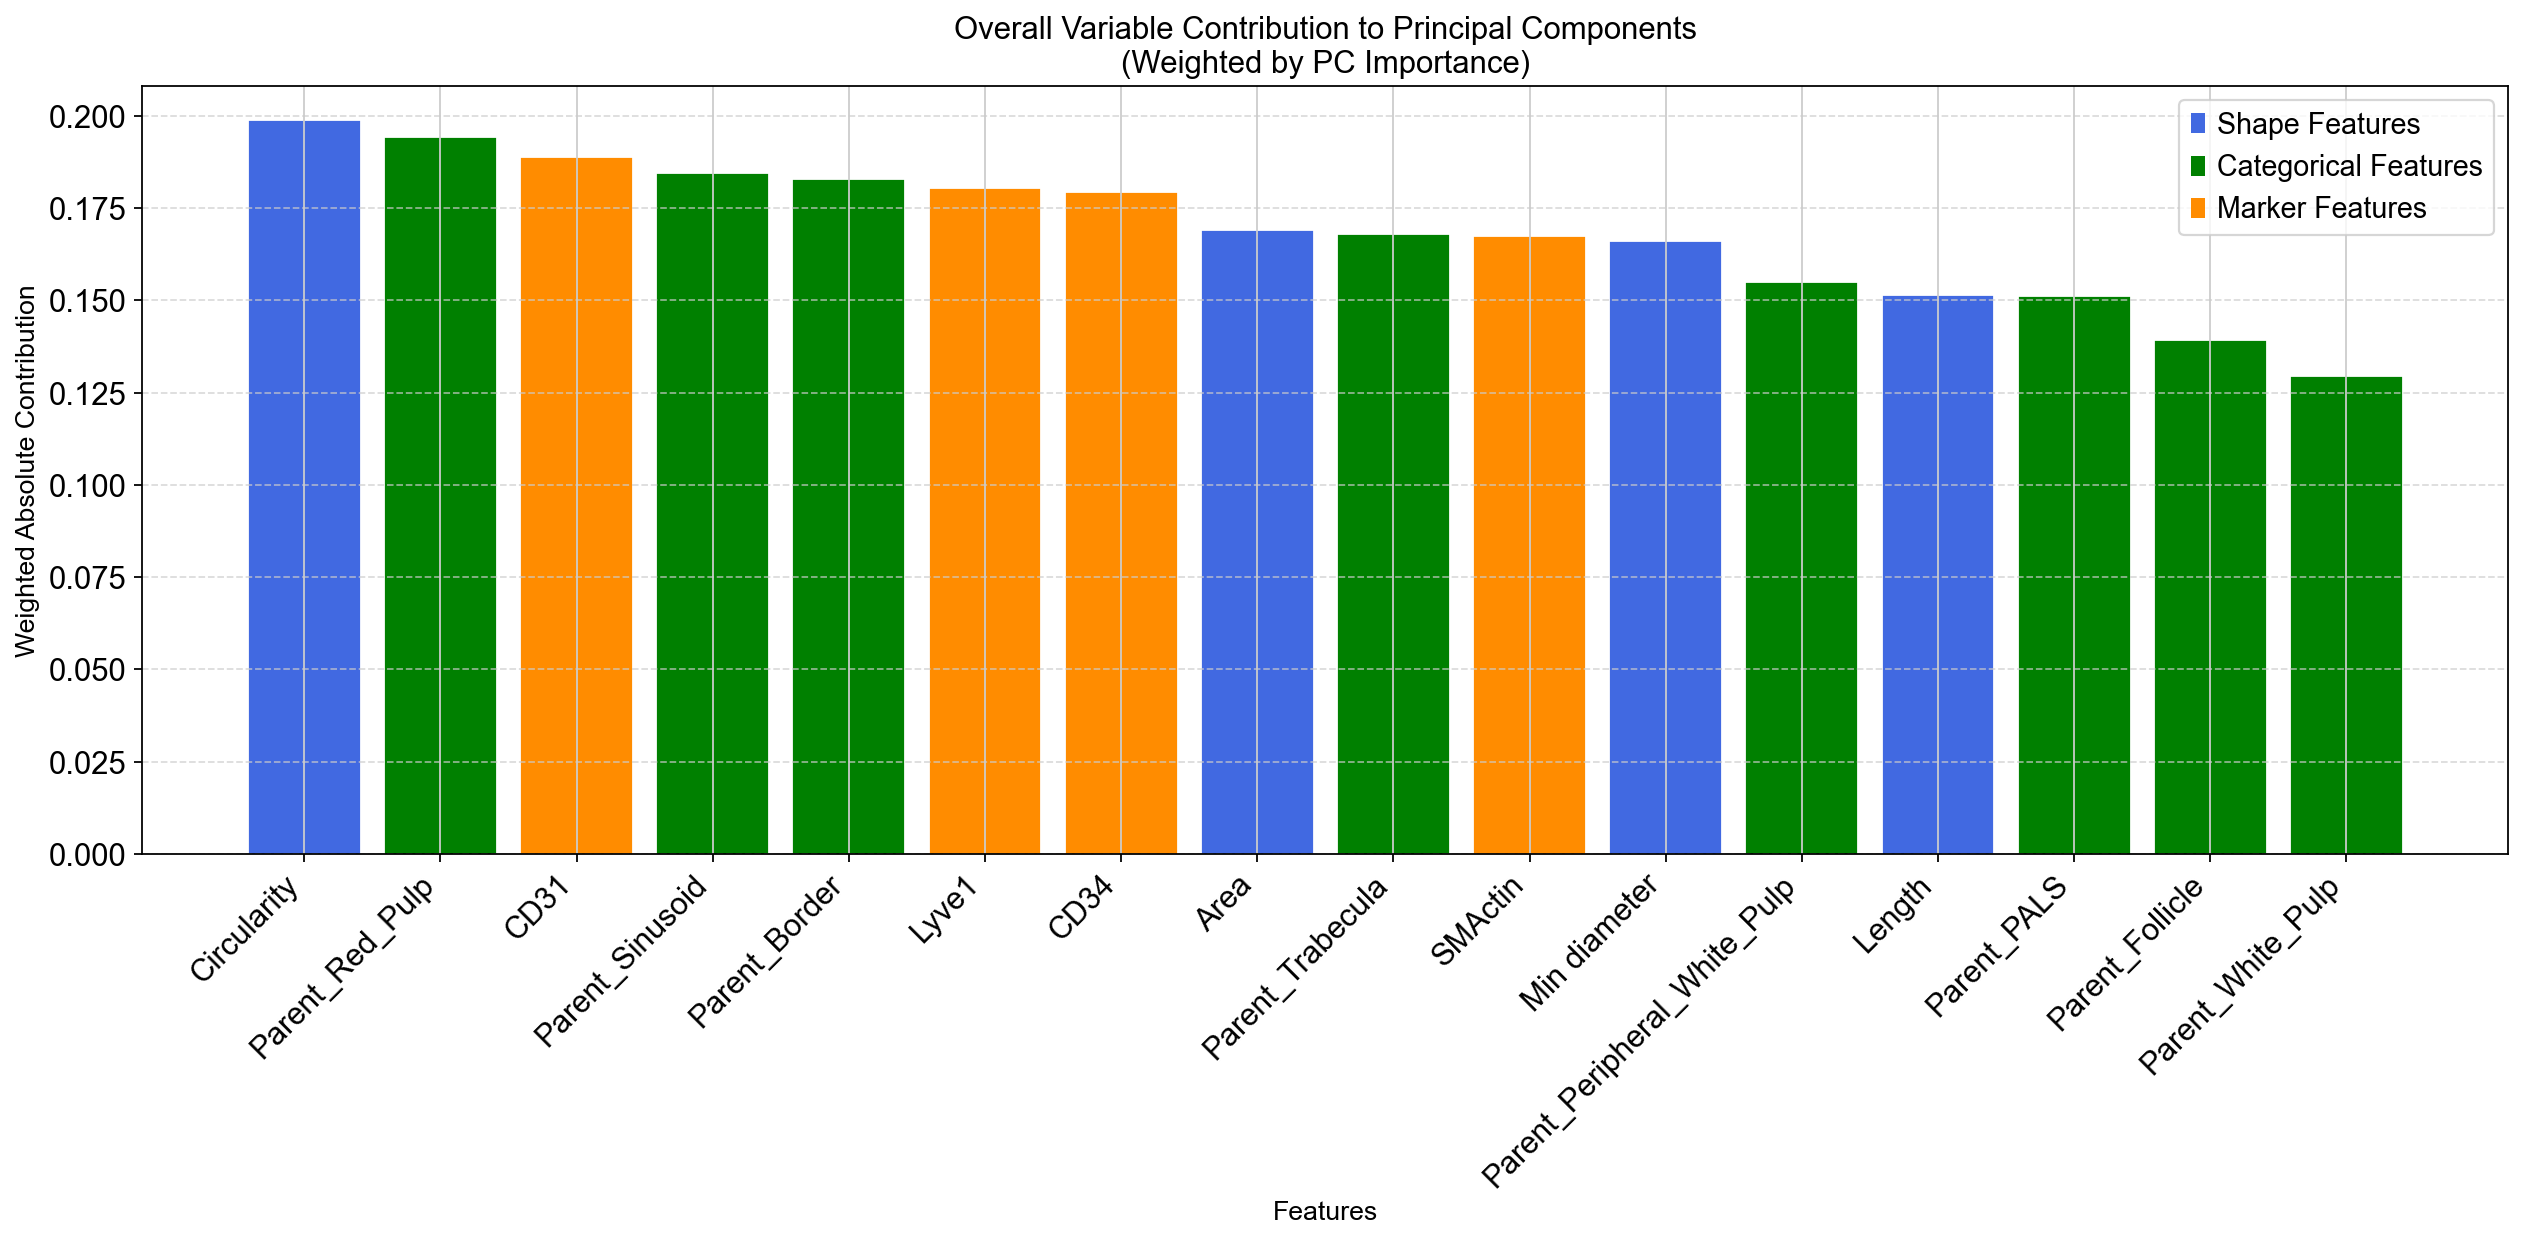

In [21]:
# Calculate weighted contributions
explained_variance_ratio = combined_adata.uns['pca']['variance_ratio']
weighted_loadings = loadings.copy()
for i in range(loadings.shape[1]-1):  # -1 to exclude Type column
    weighted_loadings.iloc[:, i] = np.abs(loadings.iloc[:, i]) * explained_variance_ratio[i]

# Sum up the absolute contributions across all PCs
total_contribution = weighted_loadings.iloc[:, :-1].sum(axis=1)  # Exclude Type column
total_contribution = total_contribution.sort_values(ascending=False)

# Plot the total contribution of each variable
plt.figure(figsize=(16, 8))
bars = plt.bar(range(len(total_contribution)), total_contribution.values)

# Color the bars by feature type
for i, (feature, value) in enumerate(total_contribution.items()):
    feature_type = get_feature_type(feature)
    bars[i].set_color(colors[feature_type])

plt.title('Overall Variable Contribution to Principal Components\n(Weighted by PC Importance)', fontsize=14)
plt.ylabel('Weighted Absolute Contribution', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(range(len(total_contribution)), total_contribution.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Shape'], label='Shape Features'),
    Patch(facecolor=colors['Categorical'], label='Categorical Features'),
    Patch(facecolor=colors['Marker'], label='Marker Features')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
print("\nTop 15 Contributing Features:")
for i, (feature, value) in enumerate(total_contribution.head(15).items()):
    feature_type = get_feature_type(feature)
    print(f"{i+1:2d}. {feature:25s} ({feature_type:11s}): {value:.4f}")

# Show feature type distribution in top contributors
top_15_types = [get_feature_type(f) for f in total_contribution.head(15).index]
print(f"\nTop 15 feature types:")
print(f"Shape: {top_15_types.count('Shape')}")
print(f"Categorical: {top_15_types.count('Categorical')}")
print(f"Marker: {top_15_types.count('Marker')}")

# Store the combined analysis results
vdata.uns['pca_combined'] = {
    'loadings': loadings,
    'total_contribution': total_contribution,
    'explained_variance_ratio': explained_variance_ratio,
    'feature_types': {
        'shape': shape_feature_names,
        'categorical': categorical_feature_names,
        'marker': marker_feature_names
    }
}


Top 15 Contributing Features:
 1. Circularity               (Shape      ): 0.1983
 2. Parent_Red_Pulp           (Categorical): 0.1936
 3. CD31                      (Marker     ): 0.1884
 4. Parent_Sinusoid           (Categorical): 0.1839
 5. Parent_Border             (Categorical): 0.1824
 6. Lyve1                     (Marker     ): 0.1798
 7. CD34                      (Marker     ): 0.1789
 8. Area                      (Shape      ): 0.1686
 9. Parent_Trabecula          (Categorical): 0.1674
10. SMActin                   (Marker     ): 0.1669
11. Min diameter              (Shape      ): 0.1657
12. Parent_Peripheral_White_Pulp (Categorical): 0.1545
13. Length                    (Shape      ): 0.1508
14. Parent_PALS               (Categorical): 0.1506
15. Parent_Follicle           (Categorical): 0.1386

Top 15 feature types:
Shape: 4
Categorical: 7
Marker: 4


In [ ]:
# Complete PCA Analysis Including Shape Measurements from .obs and Marker Intensities from .var

# Create a comprehensive dataset combining obs (shape) and var (markers)
vdata_pca = vdata.copy()

# Extract shape measurements from obs
shape_features = ['Area', 'Length', 'Circularity',  'Min diameter']
shape_data = vdata_pca.obs[shape_features].values

# Extract marker data (already in .X)
marker_data = vdata_pca.X.copy()
if 'scaled' in vdata_pca.layers:
    marker_data = vdata_pca.layers['scaled'].copy()

# Combine shape and marker data
combined_data = np.concatenate([shape_data, marker_data], axis=1)

# Create feature names
shape_feature_names = shape_features
marker_feature_names = vdata_pca.var_names.tolist()
all_feature_names = shape_feature_names + marker_feature_names

print(f"Shape features: {shape_feature_names}")
print(f"Marker features: {marker_feature_names}")
print(f"Total features: {len(all_feature_names)}")

Shape features: ['Area', 'Perimeter', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter']
Marker features: ['CD31', 'CD34', 'Lyve1', 'SMActin']
Total features: 11


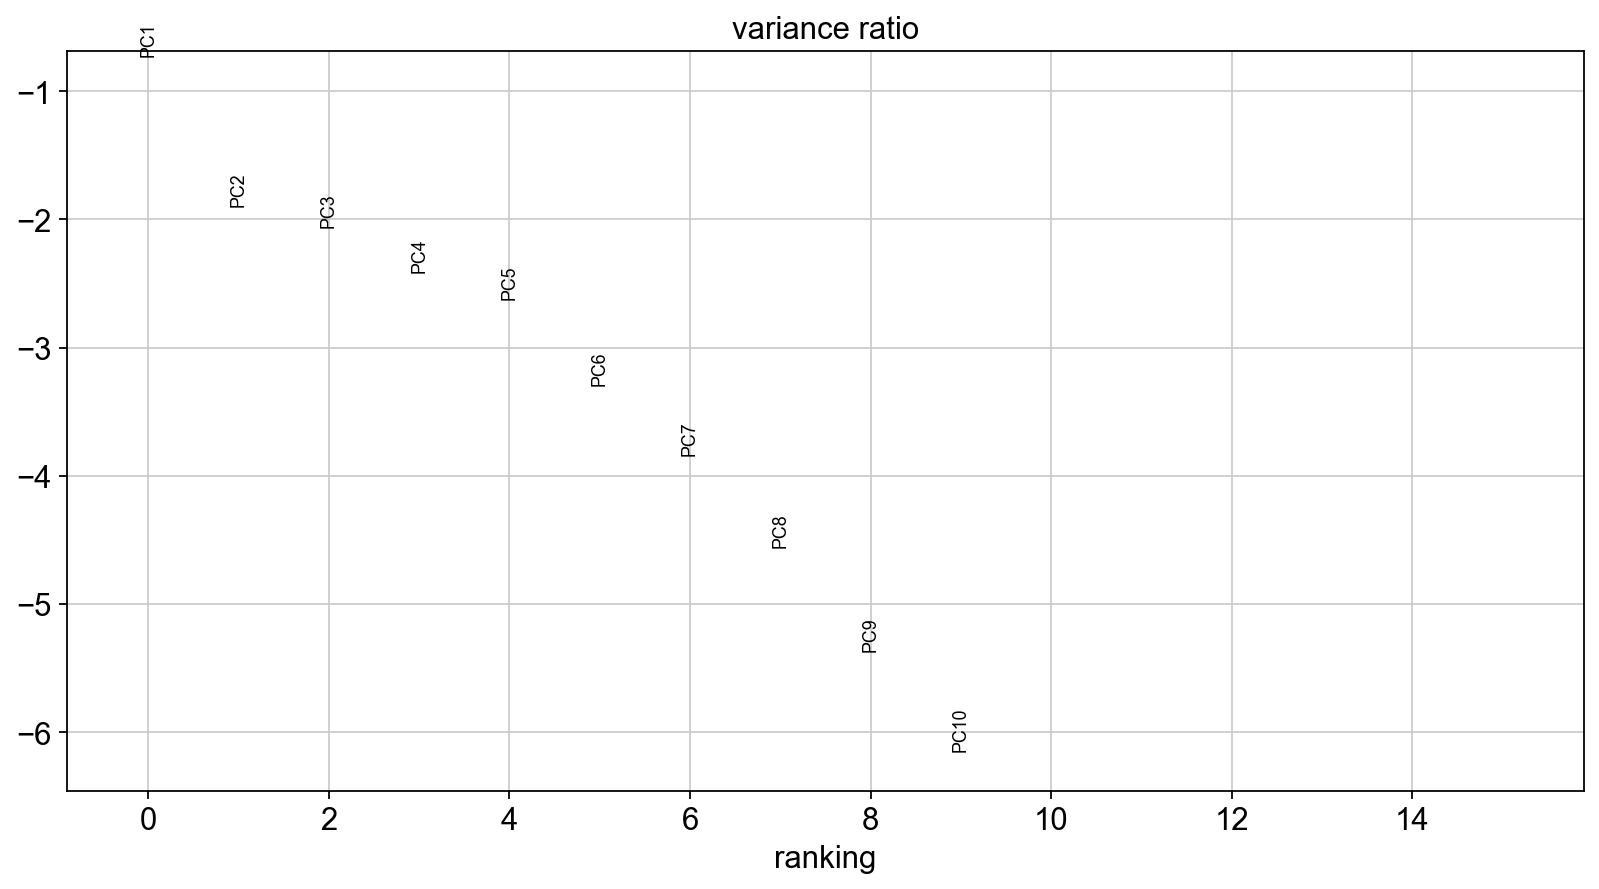


PCA Loadings (Variable Contributions):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
Area          0.397904  0.211088  0.011771 -0.066379 -0.185887 -0.153156   
Perimeter     0.428255  0.060610  0.025560 -0.032931 -0.058996 -0.034580   
Length        0.428255  0.060611  0.025561 -0.032931 -0.058997 -0.034581   
Circularity  -0.302524  0.451341  0.002861 -0.094602 -0.342339 -0.178571   
Solidity     -0.263217  0.513000 -0.020604 -0.085823 -0.389467 -0.138173   
Max diameter  0.413323  0.096133  0.036274 -0.046288 -0.069728 -0.063142   
Min diameter  0.372544  0.200917 -0.003463 -0.045878 -0.165115  0.024147   
CD31          0.026470  0.468407 -0.315402  0.052070  0.743209 -0.352071   
CD34          0.003079  0.441234  0.562208  0.140175  0.253487  0.631718   
Lyve1        -0.042144 -0.123266  0.746985  0.117383  0.085818 -0.627622   

                   PC7       PC8       PC9      PC10    Type  
Area         -0.123868  0.159088  0.830667 -0.062444   Shape

In [15]:
# Create a new AnnData object with combined data
combined_adata = ad.AnnData(X=combined_data)
combined_adata.obs = vdata_pca.obs.copy()
combined_adata.var_names = all_feature_names

# Standardize the combined data for PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
combined_adata.X = scaler.fit_transform(combined_adata.X)

# Run PCA
sc.pp.pca(combined_adata, svd_solver='arpack', n_comps=min(15, combined_adata.shape[1]-1))

# Plot variance ratio
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(12, 6))
sc.pl.pca_variance_ratio(combined_adata, n_pcs=15, log=True)

# Extract PCA loadings (variable contributions to each PC)
loadings = pd.DataFrame(
    combined_adata.varm['PCs'], 
    index=combined_adata.var_names, 
    columns=[f'PC{i+1}' for i in range(combined_adata.varm['PCs'].shape[1])]
)

# Add feature type column
loadings['Type'] = ['Shape' if feature in shape_feature_names else 'Marker' for feature in loadings.index]

print("\nPCA Loadings (Variable Contributions):")
print(loadings.head(10))

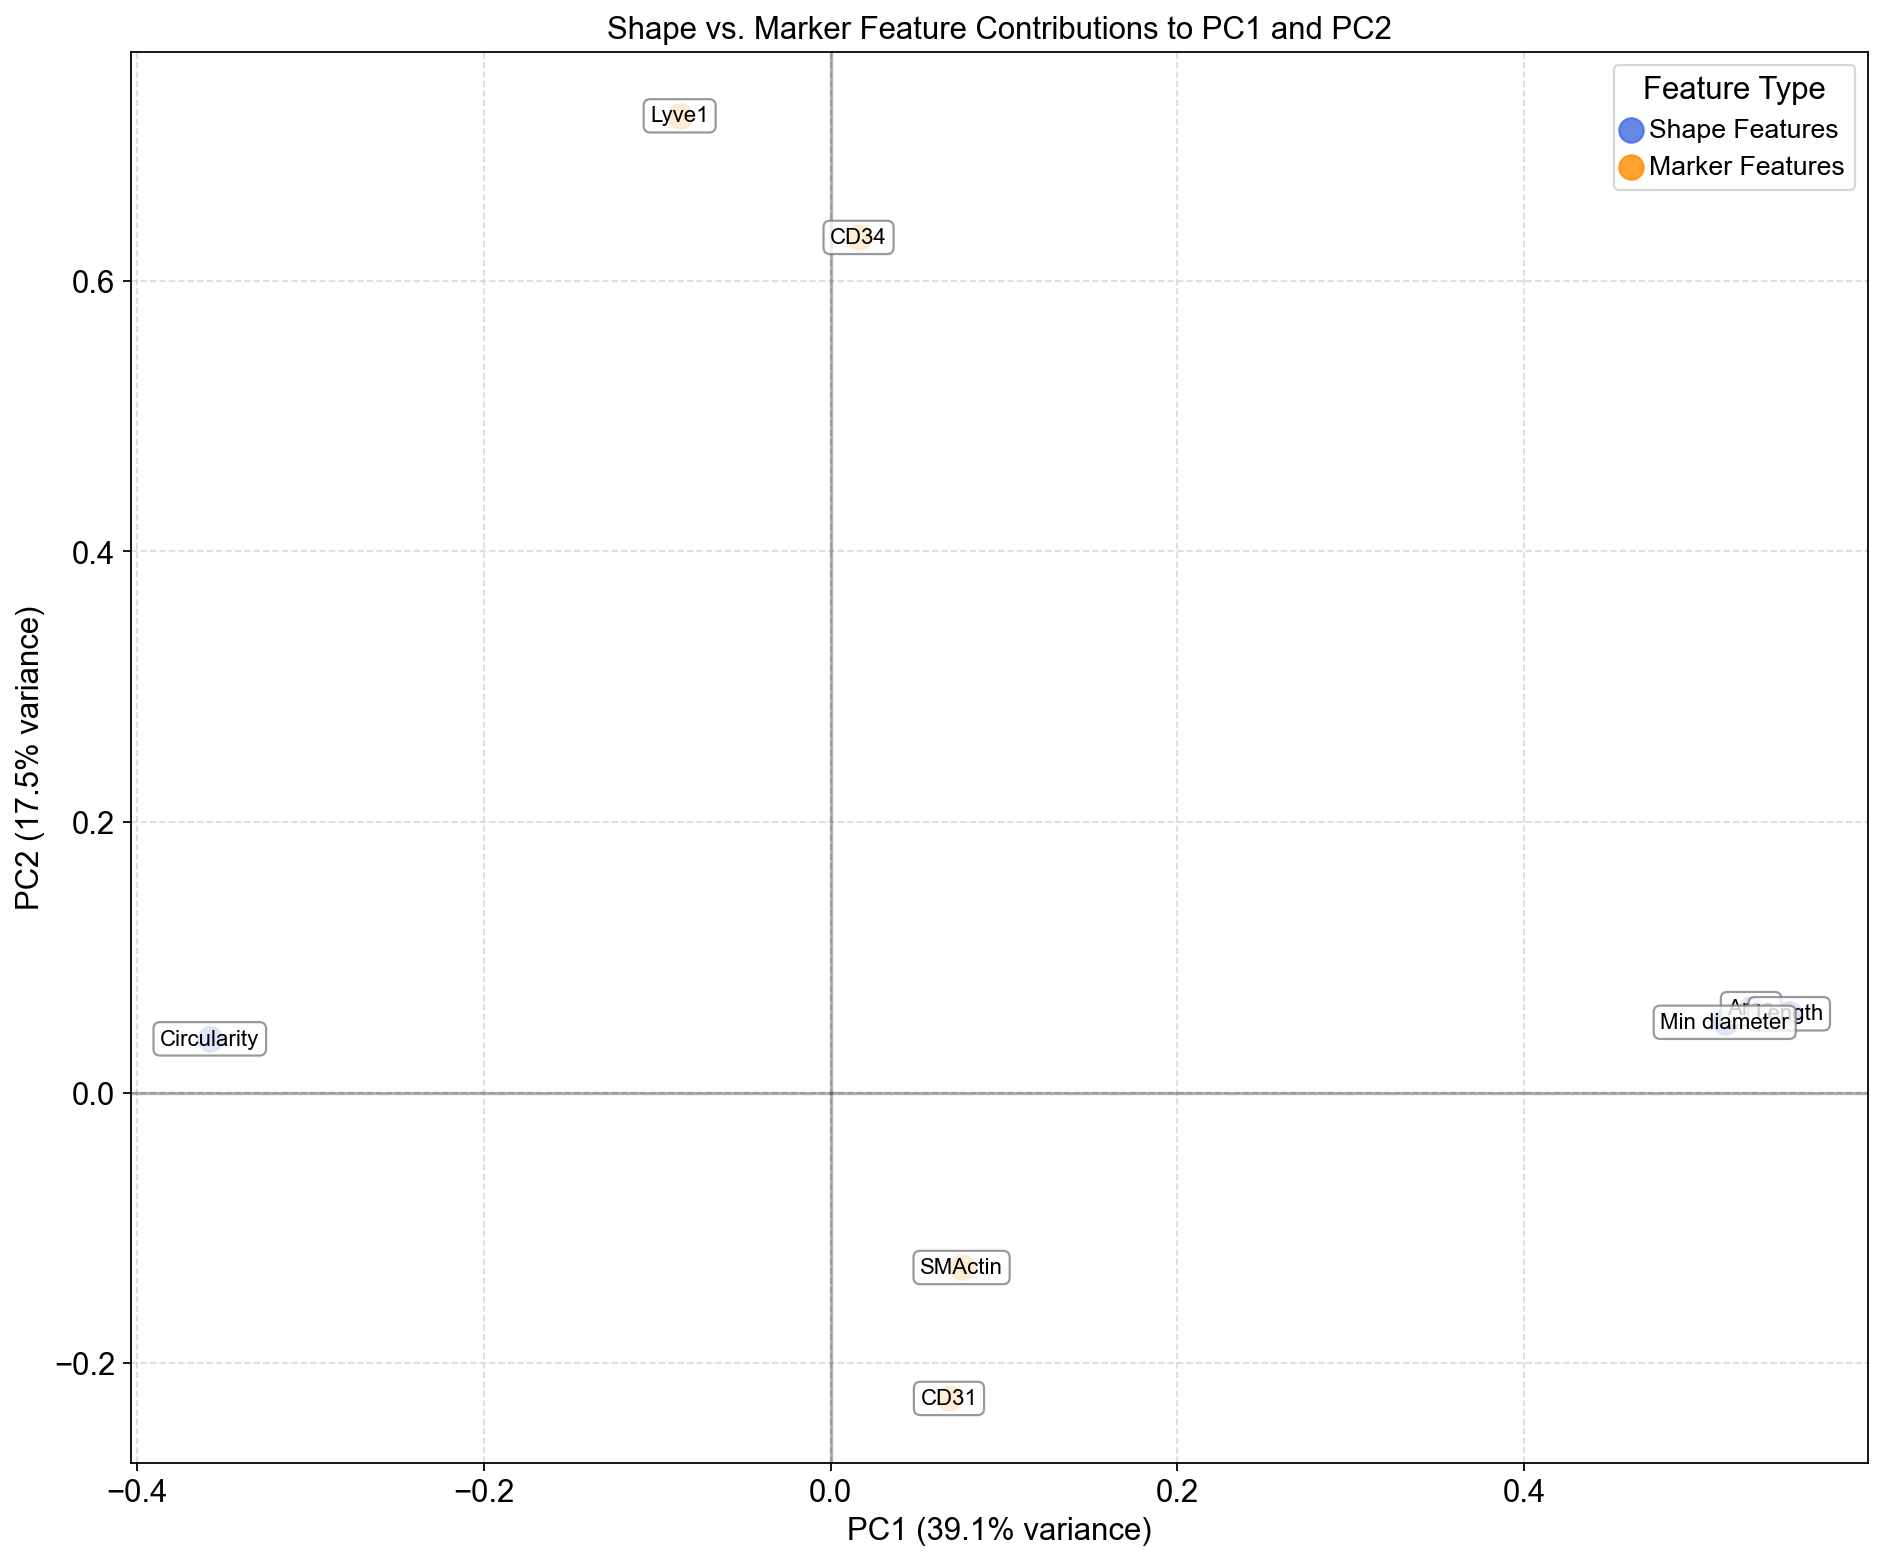

In [11]:
# Visualize the loadings for the first two PCs with feature types highlighted
plt.figure(figsize=(12, 10))
colors = {'Shape': 'royalblue', 'Marker': 'darkorange'}

for feature_type in ['Shape', 'Marker']:
    subset = loadings[loadings['Type'] == feature_type]
    plt.scatter(subset['PC1'], subset['PC2'], s=120, 
               label=f'{feature_type} Features', 
               alpha=0.8, color=colors[feature_type])

plt.grid(True, linestyle='--', alpha=0.7)

# Add variable names as annotations
for i, row in loadings.iterrows():
    plt.annotate(i, (row['PC1'], row['PC2']), 
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Add reference lines
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.xlabel(f'PC1 ({combined_adata.uns["pca"]["variance_ratio"][0]:.1%} variance)')
plt.ylabel(f'PC2 ({combined_adata.uns["pca"]["variance_ratio"][1]:.1%} variance)')
plt.title('Shape vs. Marker Feature Contributions to PC1 and PC2')
plt.legend(title='Feature Type', fontsize=12)
plt.tight_layout()
plt.show()

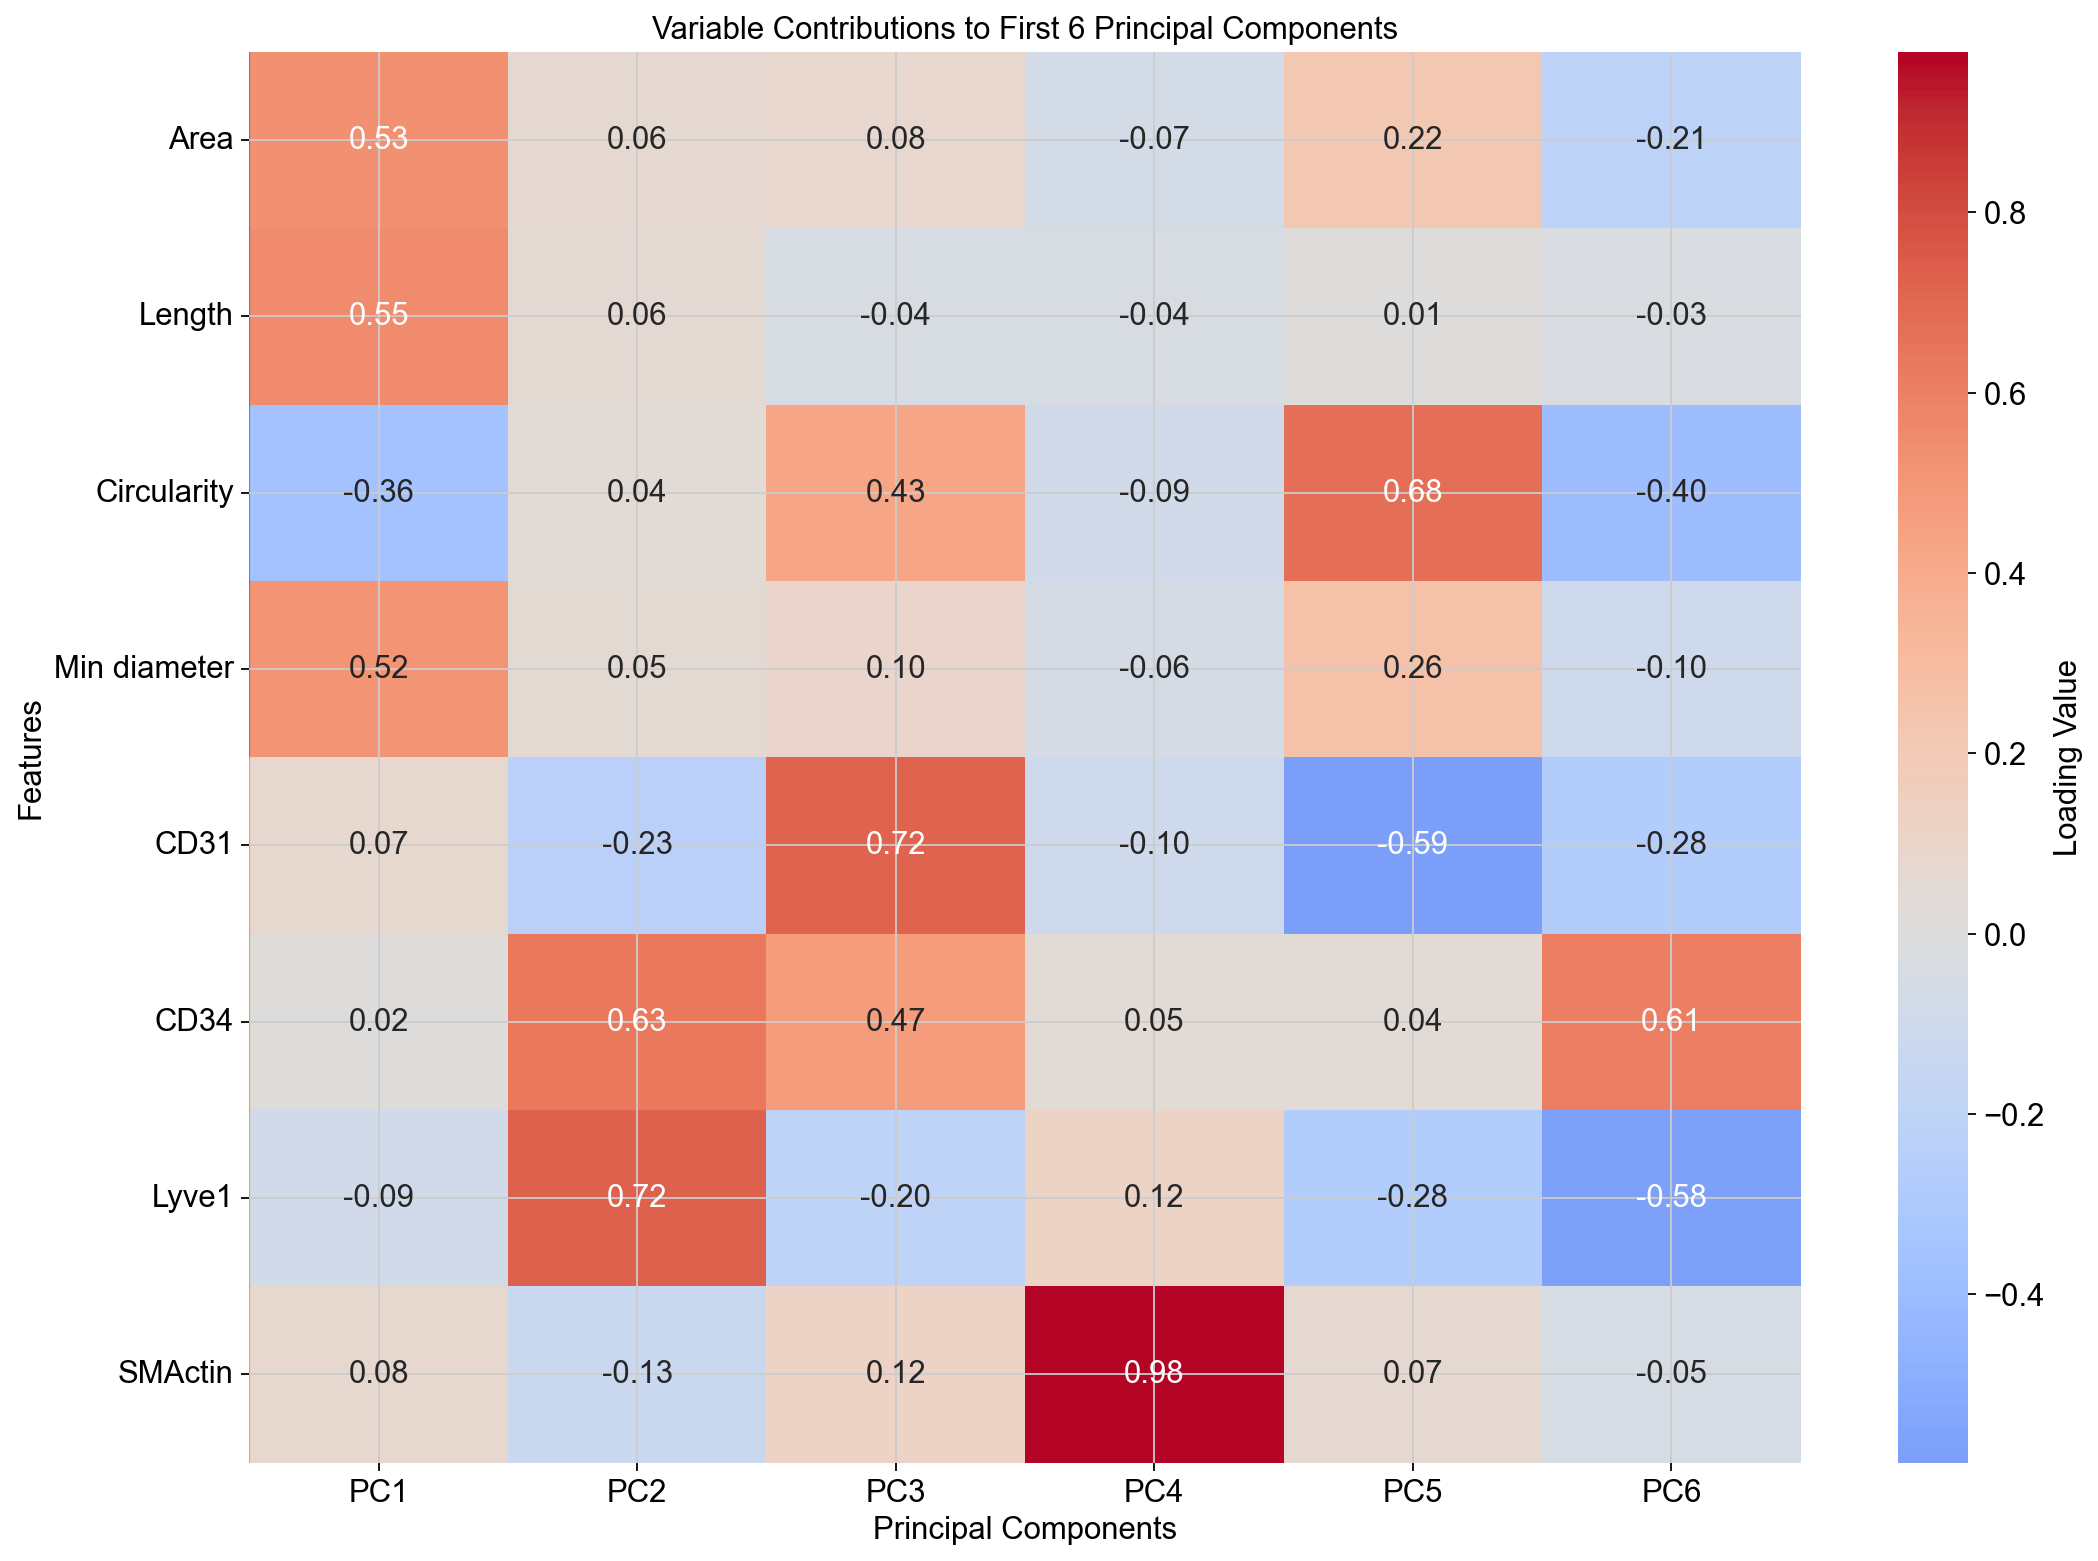

In [12]:
# Heatmap of loadings for first 6 PCs
plt.figure(figsize=(14, 10))
loadings_for_heatmap = loadings.iloc[:, :6]  # First 6 PCs
row_colors = [colors[t] for t in loadings['Type']]

# Create the heatmap
sns.heatmap(loadings_for_heatmap, annot=True, cmap='coolwarm', center=0, fmt=".2f", 
            cbar_kws={'label': 'Loading Value'})
plt.title('Variable Contributions to First 6 Principal Components')
plt.ylabel('Features')
plt.xlabel('Principal Components')

# Add colored bars for feature types
for i, (idx, row) in enumerate(loadings.iterrows()):
    plt.gca().add_patch(plt.Rectangle((-0.5, i), 0.5, 1, 
                                     color=colors[row['Type']], alpha=0.7))

plt.tight_layout()
plt.show()

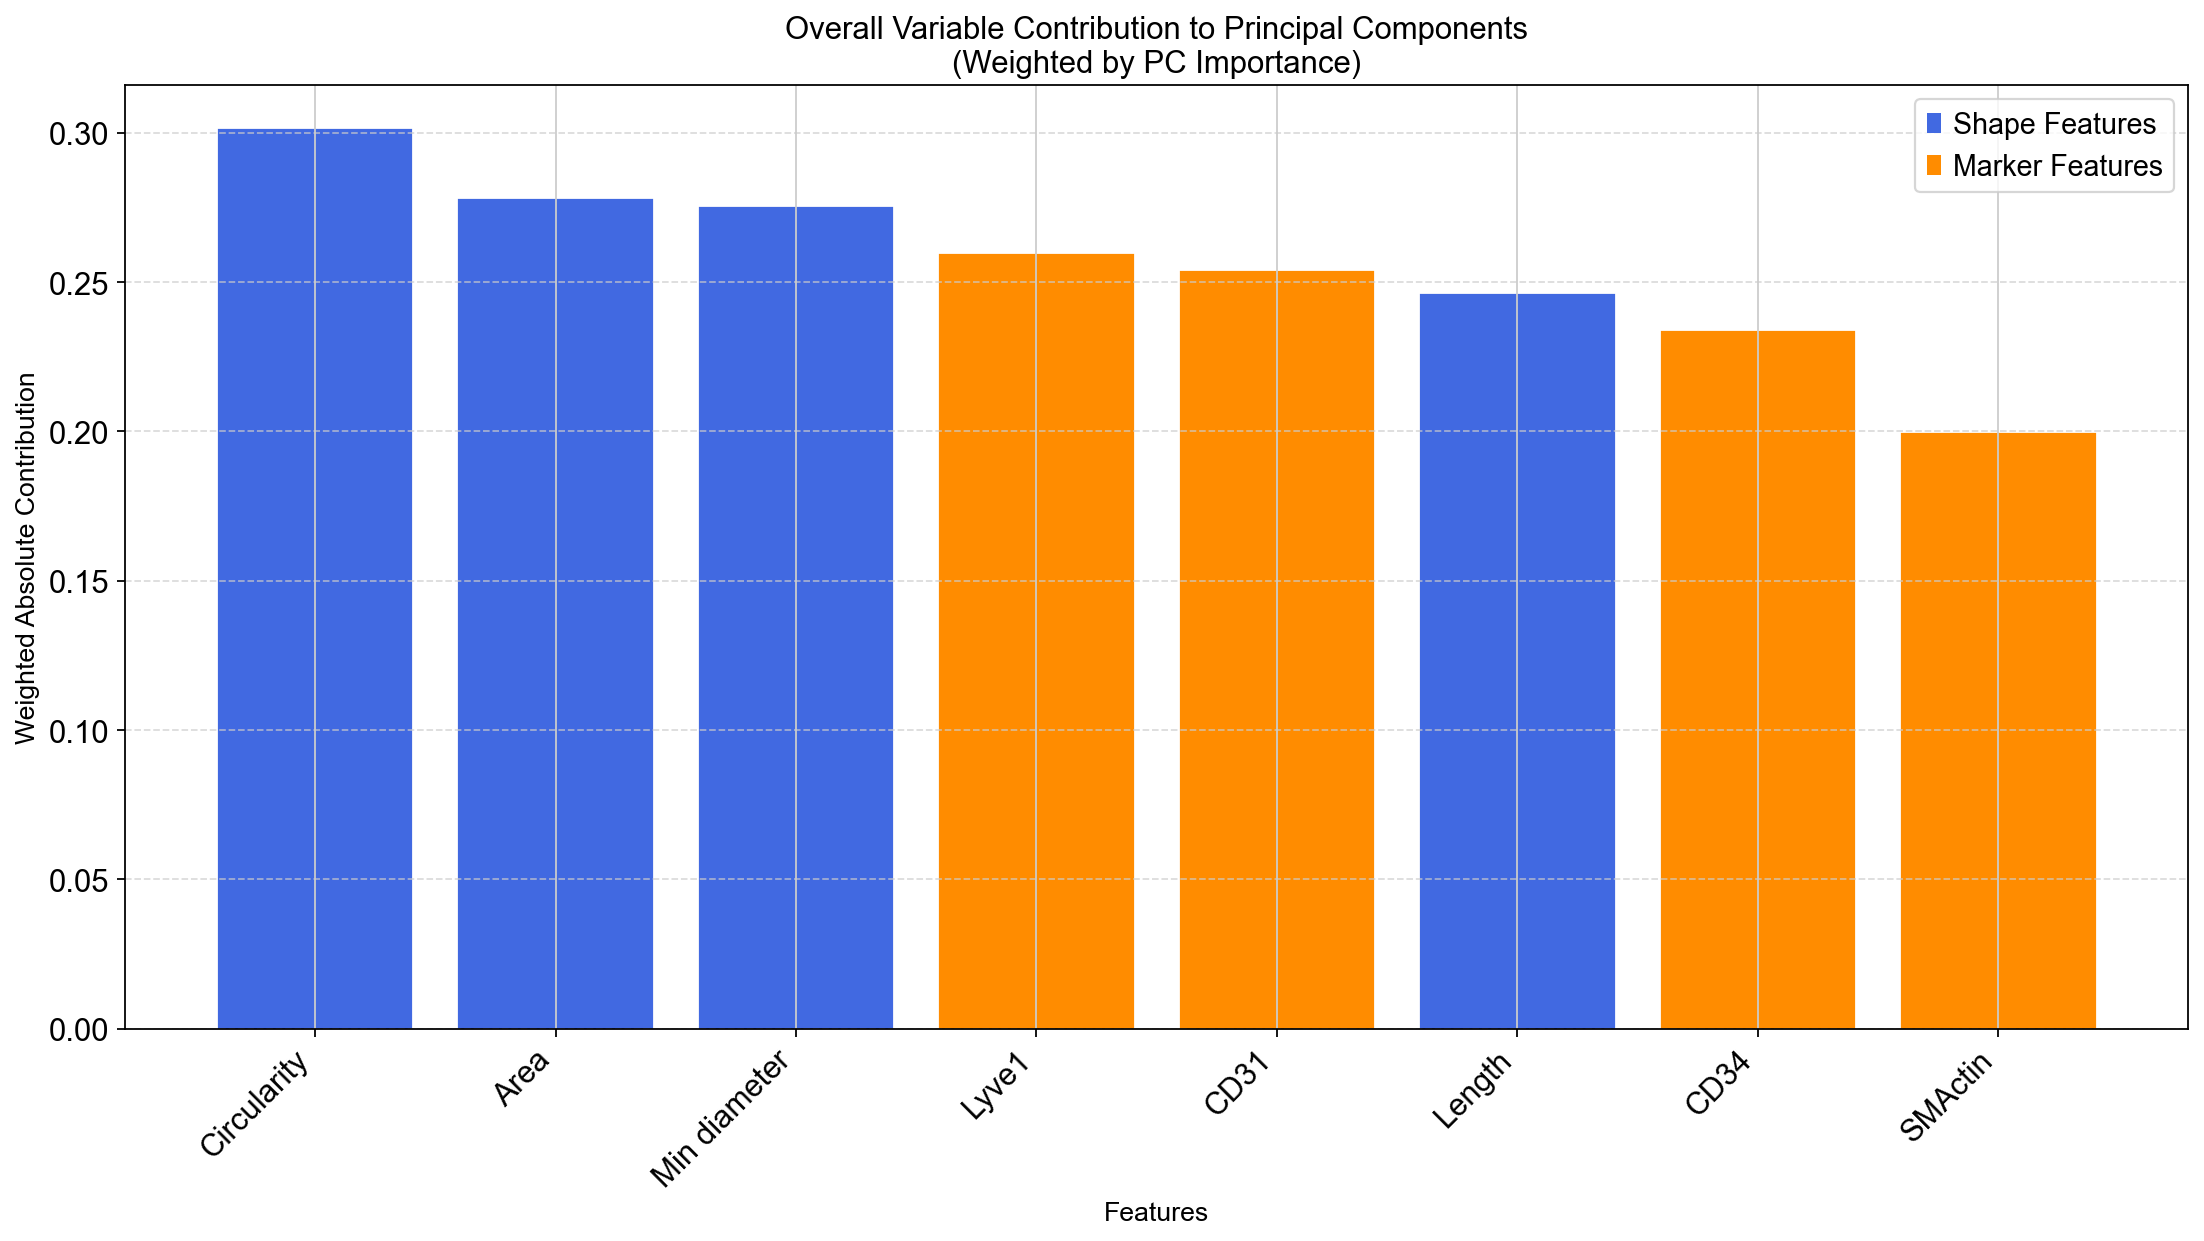

In [13]:
# Calculate weighted contributions
explained_variance_ratio = combined_adata.uns['pca']['variance_ratio']
weighted_loadings = loadings.copy()
for i in range(loadings.shape[1]-1):  # -1 to exclude Type column
    weighted_loadings.iloc[:, i] = np.abs(loadings.iloc[:, i]) * explained_variance_ratio[i]

# Sum up the absolute contributions across all PCs
total_contribution = weighted_loadings.iloc[:, :-1].sum(axis=1)  # Exclude Type column
total_contribution = total_contribution.sort_values(ascending=False)

# Plot the total contribution of each variable
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(total_contribution)), total_contribution.values)

# Color the bars by feature type
for i, (feature, value) in enumerate(total_contribution.items()):
    feature_type = 'Shape' if feature in shape_feature_names else 'Marker'
    bars[i].set_color(colors[feature_type])

plt.title('Overall Variable Contribution to Principal Components\n(Weighted by PC Importance)', fontsize=14)
plt.ylabel('Weighted Absolute Contribution', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(range(len(total_contribution)), total_contribution.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Shape'], label='Shape Features'),
    Patch(facecolor=colors['Marker'], label='Marker Features')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
print("\nTop 10 Contributing Features:")
for i, (feature, value) in enumerate(total_contribution.head(10).items()):
    feature_type = 'Shape' if feature in shape_feature_names else 'Marker'
    print(f"{i+1:2d}. {feature:15s} ({feature_type:6s}): {value:.4f}")

# Show feature type distribution in top contributors
top_10_types = [('Shape' if f in shape_feature_names else 'Marker') for f in total_contribution.head(10).index]
print(f"\nTop 10 feature types: Shape={top_10_types.count('Shape')}, Marker={top_10_types.count('Marker')}")

# Store the combined analysis results
vdata.uns['pca_combined'] = {
    'loadings': loadings,
    'total_contribution': total_contribution,
    'explained_variance_ratio': explained_variance_ratio
}


Top 10 Contributing Features:
 1. Circularity     (Shape ): 0.2641
 2. Solidity        (Shape ): 0.2593
 3. Area            (Shape ): 0.2592
 4. Min diameter    (Shape ): 0.2484
 5. Max diameter    (Shape ): 0.2434
 6. Length          (Shape ): 0.2333
 7. Perimeter       (Shape ): 0.2333
 8. CD31            (Marker): 0.1960
 9. CD34            (Marker): 0.1957
10. Lyve1           (Marker): 0.1767

Top 10 feature types: Shape=7, Marker=3


In [ ]:
vdata = vdata[vdata[:, 'Min diameter'].X.flatten() >= 0]
vdata = vdata[vdata[:, 'Max diameter'].X.flatten() >= 0]
vdata = vdata[vdata[:, 'Area'].X.flatten() >= 0]

In [ ]:
vdata = vdata[:, ['Area', 'Perimeter', 'Length', 'Circularity', 'Solidity',
       'Max diameter', 'Min diameter', 'CD31', 'CD34', 'Lyve1', 'SMActin']]

In [ ]:
sc.pp.normalize_total(vdata)
sc.pp.log1p(vdata)
vdata.layers["scaled"] = sc.pp.scale(vdata, zero_center=True, copy=True).X
# vdata.layers["raw"] = vdata.X.copy()

# # Scale only for dimensionality reduction and clustering
# # This will modify vdata.X but preserve raw values in layers["raw"]
# sc.pp.scale(vdata, zero_center=True, max_value=1)

In [ ]:
# vdata_temp = vdata.copy()
# vdata_temp.X = vdata_temp.layers['raw']
sc.pp.pca(vdata, layer="scaled")

In [ ]:
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,10))
sc.pl.pca_variance_ratio(vdata, n_pcs=30, log=True)

In [ ]:
sc.pl.pca(vdata_temp, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter',
       'Perimeter'], 
          annotate_var_explained=True)

In [ ]:
sc.pl.pca(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin'], annotate_var_explained=True)

In [ ]:
sc.pp.neighbors(vdata)
# sc.tl.paga(vdata, groups='Parent')
# sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,12))
# sc.pl.paga(vdata, fontsize=15, fontoutline= 2, layout='eq_tree', threshold=0.1, node_size_scale=8, cmap='tab20', max_edge_width=5)

In [ ]:
sc.tl.umap(vdata)

In [ ]:
sc.pl.umap(vdata, color=['Parent'], size=70)

In [ ]:
sc.pl.umap(vdata, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'],  size=30)

In [ ]:
sc.tl.leiden(vdata, resolution=0.2, key_added='leiden_Res0.2')

In [ ]:
vdata.obs.imageid.unique()

In [ ]:
vdata_2008_3A = vdata[vdata.obs['imageid'] == '20_08_CC3A'].copy()

In [ ]:
sc.tl.dendrogram(vdata, groupby='leiden_Res0.2')

In [ ]:
sc.pl.heatmap(vdata, var_names=vdata.var_names, log=False, groupby="leiden_Res0.2", dendrogram=True, use_raw=False, swap_axes=True, cmap='coolwarm', figsize=(26, 10), show_gene_labels=True, vmin=-1.25, vmax=1.25)

In [ ]:
vdata.write_h5ad('/users/smith6jt/sscore/all_SP_vessels_markers_2025July6.h5ad')

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/sscore/all_SP_vessels_markers_2025July6.h5ad')

In [ ]:
import napari
import tifffile as tiff

marker_names = ["CD107a",
"CD1c",
"CD11c",
"CD15",
"CD163",
"CD20",
"CD21",
"CD31",
"CD34",
"CD35",
"CD3e",
"CD4",
"CD45",
"CD45RO",
"CD5",
"CD68",
"CD8",
"CollagenIV",
"DAPI",
"ECAD",
"FoxP3",
"HLADR",
"Ki67",
"Lyve1",
"Podoplanin",
"SMActin",
"Vimentin"]
marker_image = tiff.imread("C:/Users/smith6jt/Spleen/Images/20_08_CC2B.tif")

clusters_df = vdata_2008_10.obs[['leiden_Res0.2','Y_centroid','X_centroid']]
unique_clusters = clusters_df['leiden_Res0.2'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

viewer = napari.Viewer()
viewer.add_image(marker_image, channel_axis=0, name=marker_names, rgb=False)

for i, cluster_id in enumerate(unique_clusters):
    cluster_points = clusters_df[clusters_df['leiden_Res0.2'] == cluster_id][['Y_centroid', 'X_centroid']].to_numpy()
    viewer.add_points(
        cluster_points*2.67,
        name=f'Cluster {cluster_id}',
        size=70,
        face_color=colors[i][:3],  
        opacity=0.7
    )


In [ ]:
vdata_2008_3A.obsm['X_spatial'] =vdata_2008_3A.obs[['X_centroid','Y_centroid']].values
fig,ax=plt.subplots(1,1,figsize=(12,12))
ax.invert_yaxis()
ax.axis('off')
sc.pl.scatter(vdata_2008_3A, basis='spatial',color=['leiden_Res0.2'], ax=ax, size=38, legend_fontsize='x-large',
              alpha=0.9, palette='tab20', title='Leiden Res0.2')

In [ ]:
sc.pl.umap(vdata, color=['leiden_Res0.2'],
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False, palette='tab20', add_outline=True, outline_width=(0.1, 0.05), size=25, title='Leiden Clusters')

In [ ]:
vdata.obs.to_csv('/Users/smith6jt/Spleen/SP_vessels_clusters.csv')

In [ ]:
# Create comprehensive plotting DataFrame
vdata_raw = vdata.copy()
vdata_raw.X = vdata_raw.layers['raw']

plot_df = pd.DataFrame({
    'Area': vdata_raw[:, 'Area'].X.flatten(),
    'Lyve1': vdata_raw[:, 'Lyve1'].X.flatten(),
    'CD31': vdata_raw[:, 'CD31'].X.flatten(),
    'CD34': vdata_raw[:, 'CD34'].X.flatten(),
    'SMActin': vdata_raw[:, 'SMActin'].X.flatten(),
    'Min_Diameter': vdata_raw[:, 'Min_Diameter'].X.flatten(),
    'imageid': vdata_raw.obs['imageid'],
    'leiden_cluster': vdata_raw.obs['leiden_Res0.2'],
    'Parent': vdata_raw.obs['Parent']
})

# Multiple plotting options
fig, axes = plt.subplots(1, 2, figsize=(24, 14))

# Plot 1: Area vs Lyve1 by image
sns.scatterplot(data=plot_df, x='Min_Diameter', y='CD34', hue='imageid', 
                palette='tab20', s=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Area vs Lyve1 by Image')

# Plot 2: Area vs Lyve1 by cluster
sns.scatterplot(data=plot_df, x='Min_Diameter', y='CD34', hue='leiden_cluster', 
                palette='turbo', s=30, alpha=0.6, ax=axes[1])
axes[1].set_title('Area vs Lyve1 by Cluster')


plt.tight_layout()
plt.show()